# Portfolio Risk & Performance Analytics Dashboard

**Asset-allocation track · Project 1 of 6.** The reporting layer every later project plugs into.

Give it a list of tickers and weights and a benchmark. It produces the report an institutional
risk committee expects each month:

| Block | What it answers |
|---|---|
| Performance | CAGR, vol, Sharpe/Sortino/Calmar, VaR/CVaR, tail shape, monthly and annual tables |
| Benchmark-relative | beta, Jensen alpha with t-stat, tracking error, information ratio, up/down capture |
| **Risk decomposition** | which positions actually drive portfolio volatility (Euler MCTR/CCTR), by asset and asset class, static and over time |
| Diversification quality | correlation in calm vs stress days, does the hedge still hedge |
| Scenarios | today's weights through eight historical stress windows |
| What-if | ex-ante impact of a proposed weight change |
| Export | a single self-contained HTML dashboard |

The central chart is *weight vs share of risk*. In the default 9-ETF portfolio, 25% in Treasuries
carries 7% of the risk while 10% in gold carries 17%. Equal-looking allocations routinely hide
concentrated risk, and that gap is what this tool is for.

**Data:** Yahoo Finance (adjusted prices), FRED (3-month T-bill). Any Yahoo symbol works; prices
are converted to a base currency automatically.

## 1. Setup

In [1]:
import importlib, subprocess, sys
def ensure(pkg, mod):
    try: importlib.import_module(mod); return
    except ImportError: pass
    for extra in ([], ["--break-system-packages"]):
        if subprocess.call([sys.executable, "-m", "pip", "install", "-q", pkg] + extra) == 0: return
    print(f"WARNING: could not install {pkg}")
for pkg, mod in [("yfinance", "yfinance"), ("scipy", "scipy")]:
    ensure(pkg, mod)
print("dependencies ready")

dependencies ready


In [2]:
import os, sys, warnings, logging, time
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING, format="%(levelname)s %(name)s: %(message)s")

USE_DRIVE = False          # persist cache/outputs to Google Drive across sessions
if USE_DRIVE:
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive"); os.chdir("/content/drive/MyDrive/portfolio-risk-analytics")

for d in ["src/riskdash", "data/cache", "outputs/figures", "outputs/tables", "tests"]:
    os.makedirs(d, exist_ok=True)
if os.path.abspath("src") not in sys.path:
    sys.path.insert(0, os.path.abspath("src"))
print("working directory:", os.getcwd())

working directory: /tmp/nb1


## 2. Package source

Written to `src/riskdash/` so the notebook is self-contained in Colab and the same code is
importable in a cloned repo.

```
portfolio-risk-analytics/
├── notebooks/portfolio_risk_analytics.ipynb
├── src/riskdash/
│   ├── config.py     portfolio, benchmark, asset classes, stress windows, settings
│   ├── data.py       Yahoo/FRED loaders, calendar alignment, FX conversion, quality gate
│   ├── metrics.py    performance, drawdown table, benchmark-relative, rolling statistics
│   ├── risk.py       simulation (drift vs rebalance), Euler decomposition, what-if, scenarios
│   ├── plots.py      figures
│   └── report.py     single-file HTML dashboard
├── tests/test_riskdash.py   12 offline tests
└── outputs/{figures,tables,dashboard.html}
```

### `riskdash/__init__.py`

Package version.

In [3]:
%%writefile src/riskdash/__init__.py
"""riskdash - portfolio risk & performance analytics dashboard (asset-allocation track, project 1)."""
__version__ = "1.0.0"

Writing src/riskdash/__init__.py


### `riskdash/config.py`

Portfolio and benchmark as `ticker -> weight` dicts (the benchmark can be a blend), an asset-class map for grouping, historical stress windows, and dashboard settings (rebalance frequency, rolling windows, VaR level).

In [4]:
%%writefile src/riskdash/config.py
"""
Configuration for the risk & performance dashboard.

A portfolio is a dict of ticker -> weight. Weights are normalised to sum to
one. The benchmark may be a single ticker or another weighted dict (for
example a 60/40 blend), which is treated exactly like a portfolio.
"""
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Dict, List, Optional

# --------------------------------------------------------------------------- #
# Default portfolio: a diversified multi-asset ETF allocation
# --------------------------------------------------------------------------- #
PORTFOLIO: Dict[str, float] = {
    "SPY": 0.30,   # US large cap
    "QQQ": 0.10,   # US growth / tech
    "EFA": 0.10,   # developed ex-US equity
    "EEM": 0.05,   # emerging markets equity
    "IEF": 0.15,   # 7-10y Treasuries
    "TLT": 0.10,   # 20y+ Treasuries
    "LQD": 0.05,   # investment-grade credit
    "GLD": 0.10,   # gold
    "VNQ": 0.05,   # US REITs
}

BENCHMARK: Dict[str, float] = {"SPY": 0.60, "AGG": 0.40}      # classic 60/40
BENCHMARK_NAME: str = "60/40 (SPY/AGG)"

# Asset-class grouping used for exposure and risk aggregation.
ASSET_CLASS: Dict[str, str] = {
    "SPY": "Equity - US", "QQQ": "Equity - US", "EFA": "Equity - Intl", "EEM": "Equity - EM",
    "IEF": "Rates", "TLT": "Rates", "AGG": "Rates", "LQD": "Credit",
    "GLD": "Commodities", "VNQ": "Real Estate",
}

# Historical stress windows (start, end) used for scenario analysis.
STRESS_SCENARIOS: Dict[str, tuple] = {
    "Euro crisis / US downgrade (2011)": ("2011-07-22", "2011-10-03"),
    "Taper tantrum (2013)": ("2013-05-02", "2013-06-24"),
    "China deval / vol spike (2015)": ("2015-08-10", "2015-08-25"),
    "Q4 2018 sell-off": ("2018-09-20", "2018-12-24"),
    "Covid crash (2020)": ("2020-02-19", "2020-03-23"),
    "Rate shock (2022)": ("2022-01-03", "2022-10-12"),
    "SVB / regional banks (2023)": ("2023-03-08", "2023-03-17"),
    "Aug 2024 yen-carry unwind": ("2024-07-16", "2024-08-05"),
}


@dataclass
class DataConfig:
    start: str = "2010-01-01"
    end: Optional[str] = None
    cache_dir: str = "data/cache"
    fred_series: str = "DGS3MO"
    base_currency: str = "USD"
    trading_days: int = 252
    min_history_fraction: float = 0.98


@dataclass
class DashboardConfig:
    rebalance: Optional[str] = "ME"     # None = buy-and-hold drift; "ME" monthly; "QE" quarterly
    rolling_window: int = 126           # ~6 months for rolling stats
    long_window: int = 756              # ~3 years for rolling Sharpe
    var_level: float = 0.95
    top_drawdowns: int = 5
    cov_window: int = 252               # window for the risk decomposition covariance


DATA = DataConfig()
DASH = DashboardConfig()

Writing src/riskdash/config.py


### `riskdash/data.py`

Downloads with retry and CSV caching, cross-exchange calendar alignment, conversion to a base currency via Yahoo FX crosses, FRED risk-free series, a quality gate that reports what it changed, and a synthetic fallback for offline runs.

In [5]:
%%writefile src/riskdash/data.py
"""
Data acquisition layer (shared across the asset-allocation track).

Responsibilities
----------------
* Download adjusted prices from Yahoo Finance with local caching.
* Download the risk-free rate from FRED (no API key required).
* Build a point-in-time market-cap proxy (current shares outstanding x
  historical price) for Black-Litterman equilibrium weights.
* Run data-quality checks and fail loudly on problems that would corrupt
  downstream estimates.
* Provide a synthetic fallback so the pipeline can be unit-tested offline.

Every public function returns pandas objects indexed by a tz-naive
DatetimeIndex and aligned to the trading calendar of the price data.
"""
from __future__ import annotations

import io
import logging
import os
import time
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import requests

from .config import DATA, DataConfig

logger = logging.getLogger(__name__)

FRED_CSV_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}"


# --------------------------------------------------------------------------- #
# Helpers
# --------------------------------------------------------------------------- #
def _cache_path(cfg: DataConfig, name: str) -> str:
    os.makedirs(cfg.cache_dir, exist_ok=True)
    return os.path.join(cfg.cache_dir, name)


def _retry(fn, attempts: int = 3, wait: float = 2.0, label: str = "call"):
    """Retry a callable with linear back-off. Re-raises the last exception."""
    last_exc: Optional[Exception] = None
    for i in range(1, attempts + 1):
        try:
            return fn()
        except Exception as exc:  # noqa: BLE001 - we want to retry on anything
            last_exc = exc
            logger.warning("%s failed (attempt %d/%d): %s", label, i, attempts, exc)
            time.sleep(wait * i)
    assert last_exc is not None
    raise last_exc


# --------------------------------------------------------------------------- #
# Prices
# --------------------------------------------------------------------------- #
def load_prices(tickers: Iterable[str],
                cfg: DataConfig = DATA,
                force_refresh: bool = False) -> pd.DataFrame:
    """
    Adjusted close prices, one column per ticker.

    Prices are cached to CSV keyed on the ticker set and date range.
    Adjusted closes (auto_adjust=True) already incorporate splits and
    dividends, so simple returns on them are total returns.
    """
    tickers = sorted(set(tickers))
    end = cfg.end or pd.Timestamp.today().strftime("%Y-%m-%d")
    cache = _cache_path(cfg, f"prices_{cfg.start}_{end}_{len(tickers)}.csv")

    if os.path.exists(cache) and not force_refresh:
        prices = pd.read_csv(cache, index_col=0, parse_dates=True)
        if set(prices.columns) == set(tickers):
            logger.info("Loaded %d tickers from cache %s", len(tickers), cache)
            return prices[tickers]

    import yfinance as yf  # imported lazily so tests can run without it

    def _download() -> pd.DataFrame:
        raw = yf.download(tickers, start=cfg.start, end=end,
                          auto_adjust=True, progress=False, threads=True)
        if raw.empty:
            raise RuntimeError("Yahoo Finance returned an empty frame")
        close = raw["Close"] if isinstance(raw.columns, pd.MultiIndex) else raw[["Close"]]
        if isinstance(close, pd.Series):
            close = close.to_frame(tickers[0])
        return close

    prices = _retry(_download, label="yfinance download")
    prices.index = pd.to_datetime(prices.index).tz_localize(None)
    prices = prices.sort_index()
    prices.columns = [str(c) for c in prices.columns]
    prices = prices.reindex(columns=tickers)

    try:
        prices.to_csv(cache)
    except Exception as exc:  # read-only filesystem etc. - caching is best-effort
        logger.warning("Could not write price cache: %s", exc)
    return prices


def clean_prices(prices: pd.DataFrame,
                 cfg: DataConfig = DATA) -> Tuple[pd.DataFrame, Dict[str, str]]:
    """
    Data-quality gate.

    * Drops tickers with insufficient history.
    * Forward-fills isolated gaps (max 5 days) and reports them.
    * Drops any leading rows where not every ticker has a price.
    * Raises on non-positive prices or on duplicated dates.

    Returns the cleaned frame and a dict of issues found, for the report.
    """
    issues: Dict[str, str] = {}
    px = prices.copy()

    if px.index.duplicated().any():
        raise ValueError("Duplicated dates in price index")

    # 1. Cross-exchange calendars: drop days on which most of the universe was
    #    closed (e.g. an Indian holiday in a mixed India/US list). Dropping a
    #    row is safe for returns because pct_change compounds across the gap;
    #    forward-filling instead would create artificial zero-return days.
    row_cov = px.notna().mean(axis=1)
    dropped_days = int((row_cov < 0.5).sum())
    if dropped_days:
        issues["_calendar"] = f"dropped {dropped_days} days when <50% of tickers traded"
    px = px[row_cov >= 0.5]

    # 2. Fill the remaining isolated gaps (single-exchange holidays, bad ticks).
    gap_counts = px.isna().sum()
    px = px.ffill(limit=5)

    # 3. Tickers with insufficient history (listed after `start`, delisted, etc).
    coverage = px.notna().mean()
    thin = coverage[coverage < cfg.min_history_fraction]
    for t, c in thin.items():
        first = px[t].first_valid_index()
        issues[t] = (f"dropped: only {c:.1%} of dates have a price"
                     + (f" (first price {first.date()}; move DataConfig.start later to keep it)" if first is not None else ""))
    px = px.drop(columns=thin.index)
    for t, n in gap_counts.reindex(px.columns).items():
        if n > 0:
            issues[t] = issues.get(t, "") + f"filled {int(n)} missing price(s)"

    px = px.dropna(how="any")          # remove leading NaNs / anything unfillable

    if (px <= 0).any().any():
        bad = px.columns[(px <= 0).any()].tolist()
        raise ValueError(f"Non-positive prices found for {bad}")

    return px, issues


def compute_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """Simple daily returns. Simple (not log) because portfolio returns aggregate linearly."""
    rets = prices.pct_change().iloc[1:]
    # Guard against corporate-action glitches that produce absurd single-day moves.
    extreme = (rets.abs() > 0.5)
    if extreme.any().any():
        n = int(extreme.sum().sum())
        logger.warning("%d daily returns exceed +/-50%%; inspect before trusting results", n)
    return rets


# --------------------------------------------------------------------------- #
# Currency conversion
# --------------------------------------------------------------------------- #
def fetch_currencies(tickers: Iterable[str]) -> pd.Series:
    """Quote currency per ticker from yfinance (e.g. USD, INR, JPY, GBp)."""
    out: Dict[str, str] = {}
    try:
        import yfinance as yf
        for t in tickers:
            try:
                out[t] = str(yf.Ticker(t).fast_info.get("currency") or "USD")
            except Exception as exc:  # noqa: BLE001
                logger.warning("currency lookup failed for %s; assuming USD: %s", t, exc)
                out[t] = "USD"
    except ImportError:
        out = {t: "USD" for t in tickers}
    return pd.Series(out, name="currency")


def convert_to_base_currency(prices: pd.DataFrame, base: str = "USD",
                             currencies: Optional[pd.Series] = None,
                             cfg: DataConfig = DATA) -> Tuple[pd.DataFrame, Dict[str, str]]:
    """
    Convert every column to `base` using Yahoo FX crosses (e.g. INRUSD=X).

    GBp (pence) and ZAc (cents) are scaled to their major unit first. FX
    series are forward-filled onto the price calendar. Returns the converted
    frame and a log of what was converted. No-op for single-currency
    universes already quoted in `base`.
    """
    log: Dict[str, str] = {}
    cur = currencies if currencies is not None else fetch_currencies(prices.columns)
    cur = cur.reindex(prices.columns).fillna(base)
    px = prices.copy()

    minor = {"GBp": ("GBP", 100.0), "ZAc": ("ZAR", 100.0), "ILA": ("ILS", 100.0)}
    for t, c in cur.items():
        if c in minor:
            major, div = minor[c]
            px[t] = px[t] / div
            cur[t] = major

    needed = sorted(set(cur) - {base})
    if not needed:
        return px, log

    import yfinance as yf
    end = cfg.end or pd.Timestamp.today().strftime("%Y-%m-%d")
    for c in needed:
        pair = f"{c}{base}=X"
        def _dl(pair=pair):
            fx = yf.download(pair, start=cfg.start, end=end, auto_adjust=True, progress=False)
            if fx.empty:
                raise RuntimeError(f"no FX data for {pair}")
            fx = fx["Close"]
            return fx.iloc[:, 0] if isinstance(fx, pd.DataFrame) else fx
        try:
            fx = _retry(_dl, label=f"FX {pair}")
        except Exception as exc:  # noqa: BLE001
            raise RuntimeError(f"Could not download {pair}; cannot express {c} assets in {base}") from exc
        fx.index = pd.to_datetime(fx.index).tz_localize(None)
        fx = fx.reindex(px.index.union(fx.index)).ffill().reindex(px.index)
        cols = [t for t, cc in cur.items() if cc == c]
        px[cols] = px[cols].mul(fx, axis=0)
        log[c] = f"{len(cols)} ticker(s) converted via {pair}"
    return px, log


# --------------------------------------------------------------------------- #
# Risk-free rate
# --------------------------------------------------------------------------- #
def load_risk_free(index: pd.DatetimeIndex,
                   cfg: DataConfig = DATA,
                   force_refresh: bool = False) -> pd.Series:
    """
    Daily risk-free rate aligned to `index`, derived from a FRED yield series
    quoted in percent (annualised, bond-equivalent). Falls back to zero with a
    loud warning if FRED is unreachable, so the pipeline never silently uses a
    stale number.
    """
    cache = _cache_path(cfg, f"fred_{cfg.fred_series}.csv")
    try:
        if os.path.exists(cache) and not force_refresh:
            raw = pd.read_csv(cache, index_col=0, parse_dates=True)
        else:
            resp = _retry(lambda: requests.get(FRED_CSV_URL.format(series=cfg.fred_series), timeout=30),
                          label="FRED download")
            resp.raise_for_status()
            raw = pd.read_csv(io.StringIO(resp.text), index_col=0, parse_dates=True)
            raw.to_csv(cache)
        yld = pd.to_numeric(raw.iloc[:, 0], errors="coerce")
    except Exception as exc:  # noqa: BLE001
        logger.error("Risk-free download failed (%s). Using 0%% - Sharpe ratios will be overstated.", exc)
        return pd.Series(0.0, index=index, name="rf_daily")

    yld = yld.reindex(index.union(yld.index)).ffill().reindex(index)
    yld = yld.fillna(0.0)
    daily = (1.0 + yld / 100.0) ** (1.0 / cfg.trading_days) - 1.0
    daily.name = "rf_daily"
    return daily


# --------------------------------------------------------------------------- #
# Synthetic fallback (offline tests / demos)
# --------------------------------------------------------------------------- #
def synthetic_prices(tickers: List[str],
                     n_days: int = 2520,
                     seed: int = 7,
                     start: str = "2015-01-01") -> pd.DataFrame:
    """
    Geometric Brownian motion with a one-factor correlation structure.
    Deterministic given `seed`. Used only when live data is unavailable.
    """
    rng = np.random.default_rng(seed)
    n = len(tickers)
    beta = rng.uniform(0.6, 1.4, n)
    idio = rng.uniform(0.15, 0.35, n) / np.sqrt(252)
    mkt = rng.normal(0.0004, 0.011, n_days)
    eps = rng.normal(0, 1, (n_days, n)) * idio
    rets = np.outer(mkt, beta) + eps + rng.uniform(0.0, 0.0003, n)
    idx = pd.bdate_range(start, periods=n_days)
    return pd.DataFrame(100 * np.cumprod(1 + rets, axis=0), index=idx, columns=tickers)


def load_all(tickers: Iterable[str], cfg: DataConfig = DATA,
             use_synthetic: bool = False) -> Dict[str, object]:
    """
    One-call loader: prices (base currency), daily returns, daily risk-free,
    and an issues log. `tickers` should include the benchmark constituents.
    """
    tickers = list(dict.fromkeys(tickers))          # de-duplicate, keep order
    if use_synthetic:
        logger.warning("Using SYNTHETIC prices - results are illustrative only")
        prices = synthetic_prices(tickers)
        issues: Dict[str, str] = {"_mode": "synthetic"}
        returns = compute_returns(prices)
        rf = pd.Series(0.02 / cfg.trading_days, index=returns.index, name="rf_daily")
    else:
        prices = load_prices(tickers, cfg)
        prices, issues = clean_prices(prices, cfg)
        prices, fx_log = convert_to_base_currency(prices, cfg.base_currency, cfg=cfg)
        prices = prices.dropna(how="any")
        issues.update({f"_fx_{k}": v for k, v in fx_log.items()})
        returns = compute_returns(prices)
        rf = load_risk_free(returns.index, cfg)
    return dict(prices=prices, returns=returns, rf=rf, issues=issues)

Writing src/riskdash/data.py


### `riskdash/metrics.py`

Every statistic in the report, computed on daily returns with the daily T-bill series as the risk-free rate. Includes a drawdown episode table (peak / trough / recovery dates and durations), monthly and annual tables, CAPM beta and alpha with a t-stat, tracking error, information ratio and capture ratios.

In [6]:
%%writefile src/riskdash/metrics.py
"""
Performance and risk metrics for daily return series.

Conventions
-----------
* 252 trading days per year.
* Sharpe / Sortino / alpha use the *daily* risk-free series, not a constant.
* Drawdowns are computed on compounded wealth.
* Benchmark-relative statistics (beta, alpha, tracking error, information
  ratio, capture ratios) take an aligned benchmark return series.
"""
from __future__ import annotations

from typing import Dict, List, Optional

import numpy as np
import pandas as pd
from scipy import stats

TRADING_DAYS = 252


# --------------------------------------------------------------------------- #
# Basic return / risk
# --------------------------------------------------------------------------- #
def cagr(r: pd.Series, periods: int = TRADING_DAYS) -> float:
    r = r.dropna()
    if len(r) == 0:
        return np.nan
    return float((1 + r).prod()) ** (periods / len(r)) - 1.0


def total_return(r: pd.Series) -> float:
    return float((1 + r.dropna()).prod() - 1.0)


def ann_vol(r: pd.Series, periods: int = TRADING_DAYS) -> float:
    return float(r.std(ddof=1) * np.sqrt(periods))


def downside_deviation(r: pd.Series, rf: Optional[pd.Series] = None,
                       periods: int = TRADING_DAYS) -> float:
    ex = _excess(r, rf)
    return float(np.sqrt(np.mean(np.minimum(ex, 0.0) ** 2)) * np.sqrt(periods))


def _excess(r: pd.Series, rf: Optional[pd.Series]) -> pd.Series:
    return r - (rf.reindex(r.index).fillna(0.0) if rf is not None else 0.0)


def sharpe(r: pd.Series, rf: Optional[pd.Series] = None, periods: int = TRADING_DAYS) -> float:
    ex = _excess(r, rf)
    sd = ex.std(ddof=1)
    return float(ex.mean() / sd * np.sqrt(periods)) if sd > 0 else np.nan


def sortino(r: pd.Series, rf: Optional[pd.Series] = None, periods: int = TRADING_DAYS) -> float:
    ex = _excess(r, rf)
    dd = np.sqrt(np.mean(np.minimum(ex, 0.0) ** 2))
    return float(ex.mean() / dd * np.sqrt(periods)) if dd > 0 else np.nan


def drawdown_series(r: pd.Series) -> pd.Series:
    wealth = (1 + r).cumprod()
    return wealth / wealth.cummax() - 1.0


def max_drawdown(r: pd.Series) -> float:
    return float(drawdown_series(r).min())


def calmar(r: pd.Series, periods: int = TRADING_DAYS) -> float:
    mdd = max_drawdown(r)
    return float(cagr(r, periods) / abs(mdd)) if mdd < 0 else np.nan


def var_cvar(r: pd.Series, level: float = 0.95) -> tuple[float, float]:
    """Historical daily VaR and CVaR at `level`, reported as positive losses."""
    q = r.quantile(1 - level)
    return float(-q), float(-r[r <= q].mean())


def tail_stats(r: pd.Series) -> Dict[str, float]:
    r = r.dropna()
    return dict(skew=float(stats.skew(r)), excess_kurtosis=float(stats.kurtosis(r)),
                best_day=float(r.max()), worst_day=float(r.min()),
                pct_positive_days=float((r > 0).mean()))


def omega_ratio(r: pd.Series, threshold_daily: float = 0.0) -> float:
    ex = r - threshold_daily
    gains, losses = ex[ex > 0].sum(), -ex[ex < 0].sum()
    return float(gains / losses) if losses > 0 else np.nan


# --------------------------------------------------------------------------- #
# Drawdown table
# --------------------------------------------------------------------------- #
def drawdown_table(r: pd.Series, top: int = 5) -> pd.DataFrame:
    """
    The `top` deepest drawdowns with peak, trough and recovery dates, depth,
    days peak-to-trough, days trough-to-recovery, and total length.
    An unrecovered drawdown has NaT recovery and its length runs to the end.
    """
    wealth = (1 + r).cumprod()
    peak = wealth.cummax()
    dd = wealth / peak - 1.0
    in_dd = dd < 0
    episodes = []
    start = None
    for i, (date, flag) in enumerate(in_dd.items()):
        if flag and start is None:
            start = i - 1 if i > 0 else 0           # last peak date
        elif not flag and start is not None:
            episodes.append((start, i))
            start = None
    if start is not None:
        episodes.append((start, None))

    rows = []
    for s, e in episodes:
        seg = dd.iloc[s: e if e is not None else len(dd)]
        trough_idx = seg.idxmin()
        rows.append(dict(peak=dd.index[s], trough=trough_idx,
                         recovery=dd.index[e] if e is not None else pd.NaT,
                         depth=float(seg.min()),
                         days_to_trough=int(dd.index.get_loc(trough_idx) - s),
                         days_to_recover=(int(e - dd.index.get_loc(trough_idx)) if e is not None else np.nan),
                         total_days=int((e if e is not None else len(dd)) - s)))
    if not rows:
        return pd.DataFrame(columns=["peak", "trough", "recovery", "depth", "days_to_trough",
                                     "days_to_recover", "total_days"])
    tbl = pd.DataFrame(rows).sort_values("depth").head(top).reset_index(drop=True)
    return tbl


# --------------------------------------------------------------------------- #
# Calendar tables
# --------------------------------------------------------------------------- #
def monthly_returns(r: pd.Series) -> pd.Series:
    return (1 + r).resample("ME").prod() - 1


def monthly_table(r: pd.Series) -> pd.DataFrame:
    """Year x month table of returns with a 'Year' total column."""
    m = monthly_returns(r)
    tbl = pd.DataFrame({"year": m.index.year, "month": m.index.month, "ret": m.values})
    piv = tbl.pivot(index="year", columns="month", values="ret")
    piv.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"][:len(piv.columns)] \
        if len(piv.columns) == 12 else [pd.Timestamp(2000, c, 1).strftime("%b") for c in piv.columns]
    piv["Year"] = (1 + piv.fillna(0)).prod(axis=1) - 1
    return piv


def annual_returns(r: pd.Series) -> pd.Series:
    return (1 + r).groupby(r.index.year).prod() - 1


# --------------------------------------------------------------------------- #
# Benchmark-relative
# --------------------------------------------------------------------------- #
def beta_alpha(r: pd.Series, bench: pd.Series, rf: Optional[pd.Series] = None,
               periods: int = TRADING_DAYS) -> Dict[str, float]:
    """CAPM beta and annualised Jensen alpha via OLS on excess returns."""
    df = pd.concat([_excess(r, rf), _excess(bench, rf)], axis=1).dropna()
    x, y = df.iloc[:, 1].values, df.iloc[:, 0].values
    slope, intercept, rvalue, pvalue, stderr = stats.linregress(x, y)
    resid_se = np.std(y - slope * x - intercept, ddof=2) / np.sqrt(len(x))
    return dict(beta=float(slope), alpha_ann=float(intercept * periods),
                r_squared=float(rvalue ** 2), beta_se=float(stderr),
                alpha_t=float(intercept / resid_se) if resid_se > 0 else np.nan)


def tracking_error(r: pd.Series, bench: pd.Series, periods: int = TRADING_DAYS) -> float:
    active = (r - bench.reindex(r.index)).dropna()
    return float(active.std(ddof=1) * np.sqrt(periods))


def information_ratio(r: pd.Series, bench: pd.Series, periods: int = TRADING_DAYS) -> float:
    active = (r - bench.reindex(r.index)).dropna()
    sd = active.std(ddof=1)
    return float(active.mean() / sd * np.sqrt(periods)) if sd > 0 else np.nan


def capture_ratios(r: pd.Series, bench: pd.Series, freq: str = "ME") -> Dict[str, float]:
    """Up/down capture on period-aggregated returns (monthly by default)."""
    p = (1 + r).resample(freq).prod() - 1
    b = (1 + bench.reindex(r.index)).resample(freq).prod() - 1
    up, down = b > 0, b < 0
    def _geo(x):
        return float((1 + x).prod() ** (1 / max(len(x), 1)) - 1) if len(x) else np.nan
    up_c = _geo(p[up]) / _geo(b[up]) if up.any() and _geo(b[up]) != 0 else np.nan
    down_c = _geo(p[down]) / _geo(b[down]) if down.any() and _geo(b[down]) != 0 else np.nan
    return dict(up_capture=up_c, down_capture=down_c,
                capture_ratio=(up_c / down_c if down_c not in (0, np.nan) and not np.isnan(down_c) else np.nan),
                hit_rate=float((p > b).mean()))


def correlation(r: pd.Series, bench: pd.Series) -> float:
    return float(pd.concat([r, bench], axis=1).dropna().corr().iloc[0, 1])


# --------------------------------------------------------------------------- #
# Rolling statistics
# --------------------------------------------------------------------------- #
def rolling_vol(r: pd.Series, window: int, periods: int = TRADING_DAYS) -> pd.Series:
    return r.rolling(window).std(ddof=1) * np.sqrt(periods)


def rolling_sharpe(r: pd.Series, rf: Optional[pd.Series], window: int,
                   periods: int = TRADING_DAYS) -> pd.Series:
    ex = _excess(r, rf)
    return ex.rolling(window).mean() / ex.rolling(window).std(ddof=1) * np.sqrt(periods)


def rolling_beta(r: pd.Series, bench: pd.Series, window: int) -> pd.Series:
    df = pd.concat([r, bench.reindex(r.index)], axis=1).dropna()
    cov = df.iloc[:, 0].rolling(window).cov(df.iloc[:, 1])
    var = df.iloc[:, 1].rolling(window).var()
    return cov / var


def rolling_correlation(r: pd.Series, bench: pd.Series, window: int) -> pd.Series:
    return r.rolling(window).corr(bench.reindex(r.index))


def rolling_drawdown(r: pd.Series, window: int) -> pd.Series:
    """Worst drawdown within each trailing window."""
    wealth = (1 + r).cumprod()
    return wealth.rolling(window).apply(lambda w: (w / np.maximum.accumulate(w) - 1).min(), raw=True)


# --------------------------------------------------------------------------- #
# Summary
# --------------------------------------------------------------------------- #
def summary(r: pd.Series, rf: Optional[pd.Series] = None,
            bench: Optional[pd.Series] = None, var_level: float = 0.95) -> Dict[str, float]:
    var_, cvar_ = var_cvar(r, var_level)
    dd_tbl = drawdown_table(r, 1)
    out = {
        "Total return": total_return(r),
        "CAGR": cagr(r),
        "Volatility": ann_vol(r),
        "Downside deviation": downside_deviation(r, rf),
        "Sharpe": sharpe(r, rf),
        "Sortino": sortino(r, rf),
        "Max drawdown": max_drawdown(r),
        "Max DD length (days)": float(dd_tbl["total_days"].iloc[0]) if len(dd_tbl) else np.nan,
        "Calmar": calmar(r),
        f"Daily VaR {var_level:.0%}": var_,
        f"Daily CVaR {var_level:.0%}": cvar_,
        "Omega": omega_ratio(r),
        "Best month": monthly_returns(r).max(),
        "Worst month": monthly_returns(r).min(),
        "% positive months": float((monthly_returns(r) > 0).mean()),
    }
    out.update({k: v for k, v in tail_stats(r).items() if k in ("skew", "excess_kurtosis")})
    if bench is not None:
        ba = beta_alpha(r, bench, rf)
        cap = capture_ratios(r, bench)
        out.update({
            "Beta": ba["beta"], "Alpha (ann)": ba["alpha_ann"], "Alpha t-stat": ba["alpha_t"],
            "R-squared": ba["r_squared"], "Correlation": correlation(r, bench),
            "Tracking error": tracking_error(r, bench),
            "Information ratio": information_ratio(r, bench),
            "Up capture": cap["up_capture"], "Down capture": cap["down_capture"],
            "Monthly hit rate": cap["hit_rate"],
        })
    return out


PCT_KEYS = {"Total return", "CAGR", "Volatility", "Downside deviation", "Max drawdown",
            "Best month", "Worst month", "% positive months", "Alpha (ann)", "Tracking error",
            "Monthly hit rate", "Up capture", "Down capture"}


def format_summary(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy().astype(object)
    for idx in out.index:
        for c in out.columns:
            v = df.loc[idx, c]
            if pd.isna(v):
                out.loc[idx, c] = ""
            elif idx in PCT_KEYS or str(idx).startswith("Daily VaR") or str(idx).startswith("Daily CVaR"):
                out.loc[idx, c] = f"{v:.2%}"
            elif "days" in str(idx):
                out.loc[idx, c] = f"{v:.0f}"
            else:
                out.loc[idx, c] = f"{v:.2f}"
    return out

Writing src/riskdash/metrics.py


### `riskdash/risk.py`

Portfolio simulation with either buy-and-hold drift or periodic rebalancing (with turnover accounting), Euler risk decomposition (marginal, component and percentage contributions, beta to portfolio, diversification ratio), rolling risk shares using drifted holdings, what-if analysis, historical stress tests and calm-vs-stress correlation.

In [7]:
%%writefile src/riskdash/risk.py
"""
Portfolio construction, risk decomposition and scenario analysis.

Risk decomposition (Euler)
--------------------------
For portfolio volatility sigma_p = sqrt(w' Sigma w):

    MCTR_i = (Sigma w)_i / sigma_p          marginal contribution to risk
    CCTR_i = w_i * MCTR_i                    component contribution (sums to sigma_p)
    PCTR_i = CCTR_i / sigma_p                percentage contribution (sums to 1)

A 5% weight can be 20% of the risk if the asset is volatile and correlated
with the rest of the book; that gap between weight and risk share is the
central message of a risk dashboard.
"""
from __future__ import annotations

import logging
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

from . import metrics as met
from .config import DASH, STRESS_SCENARIOS, DashboardConfig

logger = logging.getLogger(__name__)


# --------------------------------------------------------------------------- #
# Weights
# --------------------------------------------------------------------------- #
def normalise_weights(w: Dict[str, float]) -> pd.Series:
    s = pd.Series(w, dtype=float)
    if (s < 0).any():
        raise ValueError("Negative weights are not supported in this dashboard")
    if s.sum() <= 0:
        raise ValueError("Weights must sum to a positive number")
    if abs(s.sum() - 1.0) > 1e-6:
        logger.info("Weights sum to %.4f; normalising to 1", s.sum())
    return s / s.sum()


# --------------------------------------------------------------------------- #
# Simulation
# --------------------------------------------------------------------------- #
def _segment(w0: np.ndarray, seg: pd.DataFrame) -> Tuple[pd.Series, pd.DataFrame]:
    growth = (1.0 + seg.values).cumprod(axis=0)
    value = growth * w0
    total = value.sum(axis=1)
    ret = np.empty(len(seg))
    ret[0] = total[0] - 1.0
    ret[1:] = total[1:] / total[:-1] - 1.0
    return (pd.Series(ret, index=seg.index),
            pd.DataFrame(value / total[:, None], index=seg.index, columns=seg.columns))


def simulate(returns: pd.DataFrame, weights: pd.Series,
             rebalance: Optional[str] = "ME") -> Tuple[pd.Series, pd.DataFrame, pd.Series]:
    """
    Portfolio daily returns and daily drifted holdings.

    rebalance : pandas offset alias ("ME", "QE", "YE") or None for buy-and-hold.
    Returns (portfolio_returns, holdings, traded) where `traded` is the sum of
    absolute weight changes on each rebalance date (turnover accounting).
    """
    weights = weights.reindex(returns.columns).fillna(0.0)
    w = weights.values
    if rebalance is None:
        ret, hold = _segment(w, returns)
        traded = pd.Series(0.0, index=returns.index)
        return ret, hold, traded

    period_ends = returns.resample(rebalance).last().index
    # map period ends to actual trading days
    locs = sorted(set(returns.index.searchsorted(d, side="right") - 1 for d in period_ends))
    locs = [l for l in locs if 0 <= l < len(returns) - 1]
    bounds = [0] + [l + 1 for l in locs] + [len(returns)]
    rets, holds, traded = [], [], pd.Series(0.0, index=returns.index)
    prev_hold = None
    for a, b in zip(bounds[:-1], bounds[1:]):
        if b <= a:
            continue
        seg = returns.iloc[a:b]
        if prev_hold is not None:
            traded.iloc[a] = float(np.abs(w - prev_hold).sum())
        r, h = _segment(w, seg)
        rets.append(r); holds.append(h)
        prev_hold = h.iloc[-1].values
    return pd.concat(rets), pd.concat(holds), traded


def build_series(returns: pd.DataFrame, spec: Dict[str, float],
                 rebalance: Optional[str], name: str) -> Tuple[pd.Series, pd.DataFrame, pd.Series]:
    w = normalise_weights(spec)
    missing = [t for t in w.index if t not in returns.columns]
    if missing:
        raise KeyError(f"Tickers missing from returns: {missing}")
    port, hold, traded = simulate(returns[w.index], w, rebalance)
    port.name = name
    return port, hold, traded


# --------------------------------------------------------------------------- #
# Risk decomposition
# --------------------------------------------------------------------------- #
def risk_decomposition(weights: pd.Series, cov: pd.DataFrame) -> pd.DataFrame:
    """
    Per-asset table: weight, stand-alone vol, marginal / component / percent
    contribution to portfolio vol, beta to the portfolio, and the ratio of
    risk share to weight share (>1 means the asset punches above its weight).
    """
    assets = list(cov.index)
    w = weights.reindex(assets).fillna(0.0).values
    S = cov.values
    port_var = float(w @ S @ w)
    port_vol = np.sqrt(port_var)
    mctr = S @ w / port_vol
    cctr = w * mctr
    pctr = cctr / port_vol
    beta = (S @ w) / port_var
    tbl = pd.DataFrame({
        "weight": w,
        "stand_alone_vol": np.sqrt(np.diag(S)),
        "marginal_ctr": mctr,
        "component_ctr": cctr,
        "pct_of_risk": pctr,
        "beta_to_portfolio": beta,
        "risk_to_weight": np.where(w > 0, pctr / np.where(w > 0, w, 1), np.nan),
    }, index=assets)
    tbl.attrs["portfolio_vol"] = port_vol
    tbl.attrs["diversification_ratio"] = float((w * np.sqrt(np.diag(S))).sum() / port_vol)
    tbl.attrs["effective_n_risk"] = float(1.0 / np.sum(pctr ** 2))
    return tbl


def group_decomposition(decomp: pd.DataFrame, mapping: Dict[str, str]) -> pd.DataFrame:
    grp = pd.Series({t: mapping.get(t, "Other") for t in decomp.index})
    out = decomp.groupby(grp)[["weight", "component_ctr", "pct_of_risk"]].sum()
    out["risk_to_weight"] = out["pct_of_risk"] / out["weight"]
    return out.sort_values("pct_of_risk", ascending=False)


def rolling_risk_contribution(holdings: pd.DataFrame, returns: pd.DataFrame,
                              window: int = 252, freq: str = "ME") -> pd.DataFrame:
    """Percent risk contribution using drifted holdings and a trailing covariance, at period ends."""
    dates = holdings.resample(freq).last().index
    rows = {}
    for d in dates:
        loc = returns.index.searchsorted(d, side="right") - 1
        if loc < window:
            continue
        date = returns.index[loc]
        cov = returns.iloc[loc - window + 1: loc + 1].cov() * met.TRADING_DAYS
        w = holdings.loc[:date].iloc[-1]
        rows[date] = risk_decomposition(w, cov)["pct_of_risk"]
    return pd.DataFrame(rows).T


# --------------------------------------------------------------------------- #
# What-if
# --------------------------------------------------------------------------- #
def what_if(weights: pd.Series, cov: pd.DataFrame, mu: Optional[pd.Series],
            changes: Dict[str, float]) -> pd.DataFrame:
    """
    Apply weight changes (absolute, e.g. {"TLT": -0.05, "GLD": +0.05}), renormalise,
    and compare ex-ante vol, risk shares and (if mu given) expected return.
    """
    new = weights.copy()
    for t, dw in changes.items():
        if t not in new.index:
            raise KeyError(f"{t} not in portfolio")
        new[t] = max(new[t] + dw, 0.0)
    new = new / new.sum()
    before, after = risk_decomposition(weights, cov), risk_decomposition(new, cov)
    tbl = pd.DataFrame({
        "weight_before": before["weight"], "weight_after": after["weight"],
        "risk_share_before": before["pct_of_risk"], "risk_share_after": after["pct_of_risk"],
    })
    tbl.attrs["vol_before"] = before.attrs["portfolio_vol"]
    tbl.attrs["vol_after"] = after.attrs["portfolio_vol"]
    if mu is not None:
        tbl.attrs["ret_before"] = float(mu.reindex(weights.index).fillna(0) @ weights)
        tbl.attrs["ret_after"] = float(mu.reindex(new.index).fillna(0) @ new)
    return tbl


# --------------------------------------------------------------------------- #
# Scenarios and regimes
# --------------------------------------------------------------------------- #
def stress_test(returns: pd.DataFrame, weights: pd.Series, bench: pd.Series,
                scenarios: Dict[str, tuple] = STRESS_SCENARIOS) -> pd.DataFrame:
    """
    Historical scenario P&L: apply *today's* weights (buy-and-hold within the
    window) to the actual asset returns over each stress window. Also reports
    the benchmark and the worst single day inside the window.
    """
    rows = []
    for name, (a, b) in scenarios.items():
        seg = returns.loc[a:b, weights.index]
        if len(seg) < 3:
            continue
        port, _ = _segment(weights.values, seg)
        bseg = bench.loc[a:b]
        rows.append(dict(scenario=name, start=seg.index[0].date(), end=seg.index[-1].date(),
                         days=len(seg), portfolio=met.total_return(port), benchmark=met.total_return(bseg),
                         worst_day=float(port.min()),
                         worst_asset=seg.apply(met.total_return).idxmin(),
                         worst_asset_return=float(seg.apply(met.total_return).min())))
    return pd.DataFrame(rows).set_index("scenario")


def correlation_regimes(returns: pd.DataFrame, bench: pd.Series,
                        quantile: float = 0.10) -> Dict[str, pd.DataFrame]:
    """
    Average pairwise correlation in the worst `quantile` of benchmark days versus
    all days. Correlations rising in the tail is the diversification failure
    every multi-asset investor should be looking for.
    """
    b = bench.reindex(returns.index)
    cut = b.quantile(quantile)
    stress = returns[b <= cut]
    calm = returns[b > cut]
    def _avg(c):
        m = c.values[np.triu_indices(len(c), 1)]
        return float(np.nanmean(m))
    full_c, stress_c, calm_c = returns.corr(), stress.corr(), calm.corr()
    summary = pd.DataFrame({
        "avg_pairwise_corr": [_avg(full_c), _avg(calm_c), _avg(stress_c)],
        "n_days": [len(returns), len(calm), len(stress)],
    }, index=["All days", f"Benchmark above {quantile:.0%} tail", f"Benchmark worst {quantile:.0%} days"])
    # Per-asset correlation to the benchmark by regime: a hedge that only
    # works on calm days is not a hedge.
    to_bench = pd.DataFrame({
        "calm": calm.corrwith(b[b > cut]),
        "stress": stress.corrwith(b[b <= cut]),
    })
    to_bench["change"] = to_bench["stress"] - to_bench["calm"]
    to_bench["avg_ret_on_stress_days"] = stress.mean()
    return dict(summary=summary, full=full_c, stress=stress_c, calm=calm_c,
                to_benchmark=to_bench.sort_values("stress"))


def exposure_by_group(weights: pd.Series, mapping: Dict[str, str]) -> pd.Series:
    grp = pd.Series({t: mapping.get(t, "Other") for t in weights.index})
    return weights.groupby(grp).sum().sort_values(ascending=False)


# --------------------------------------------------------------------------- #
# End-to-end
# --------------------------------------------------------------------------- #
def run_dashboard(returns: pd.DataFrame, rf: pd.Series, portfolio: Dict[str, float],
                  benchmark: Dict[str, float], benchmark_name: str,
                  asset_class: Dict[str, str], cfg: DashboardConfig = DASH) -> Dict[str, object]:
    """Compute everything the dashboard shows and return it in one dict."""
    w = normalise_weights(portfolio)
    port, hold, traded = build_series(returns, portfolio, cfg.rebalance, "Portfolio")
    bench, _, _ = build_series(returns, benchmark, "ME", benchmark_name)
    bh, _, _ = build_series(returns, portfolio, None, "Portfolio (buy & hold)")
    idx = port.index.intersection(bench.index)
    port, bench, bh = port.loc[idx], bench.loc[idx], bh.loc[idx]

    cov_window = returns[w.index].iloc[-cfg.cov_window:]
    cov = cov_window.cov() * met.TRADING_DAYS
    mu = returns[w.index].mean() * met.TRADING_DAYS
    decomp = risk_decomposition(w, cov)

    summ = pd.DataFrame({
        "Portfolio": met.summary(port, rf, bench, cfg.var_level),
        benchmark_name: met.summary(bench, rf, None, cfg.var_level),
        "Portfolio (buy & hold)": met.summary(bh, rf, bench, cfg.var_level),
    })
    per_asset = pd.DataFrame({t: met.summary(returns[t].loc[idx], rf, bench, cfg.var_level) for t in w.index})

    rolling = pd.DataFrame({
        "vol": met.rolling_vol(port, cfg.rolling_window),
        "bench_vol": met.rolling_vol(bench, cfg.rolling_window),
        "beta": met.rolling_beta(port, bench, cfg.rolling_window),
        "corr": met.rolling_correlation(port, bench, cfg.rolling_window),
        "sharpe_3y": met.rolling_sharpe(port, rf, cfg.long_window),
        "bench_sharpe_3y": met.rolling_sharpe(bench, rf, cfg.long_window),
        "drawdown": met.drawdown_series(port),
        "bench_drawdown": met.drawdown_series(bench),
    })

    return dict(
        weights=w, portfolio=port, benchmark=bench, buy_hold=bh, holdings=hold, traded=traded,
        cov=cov, mu=mu, decomposition=decomp,
        group_decomposition=group_decomposition(decomp, asset_class),
        exposure=exposure_by_group(w, asset_class),
        summary=summ, per_asset=per_asset, rolling=rolling,
        drawdowns=met.drawdown_table(port, cfg.top_drawdowns),
        bench_drawdowns=met.drawdown_table(bench, cfg.top_drawdowns),
        monthly=met.monthly_table(port), annual=pd.DataFrame({"Portfolio": met.annual_returns(port),
                                                             benchmark_name: met.annual_returns(bench)}),
        stress=stress_test(returns, w, bench),
        regimes=correlation_regimes(returns[w.index].loc[idx], bench),
        rolling_risk=rolling_risk_contribution(hold, returns[w.index], cfg.cov_window),
        benchmark_name=benchmark_name,
    )

Writing src/riskdash/risk.py


### `riskdash/plots.py`

One function per figure; consistent style; nothing calls `plt.show()`.

In [8]:
%%writefile src/riskdash/plots.py
"""
Dashboard figures. Each function returns a matplotlib Figure; nothing here
calls plt.show(), so the notebook and the HTML report control display.
"""
from __future__ import annotations

import os
from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, PercentFormatter

from . import metrics as met

PALETTE = ["#1f4e79", "#c0392b", "#e67e22", "#27ae60", "#8e44ad",
           "#16a085", "#7f8c8d", "#d4ac0d", "#2c3e50", "#e84393"]
PORT_COLOR, BENCH_COLOR, BH_COLOR = "#1f4e79", "#7f8c8d", "#e67e22"
_pct = PercentFormatter(1.0, decimals=0)
_pct1 = PercentFormatter(1.0, decimals=1)


def set_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": "white",
        "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
        "axes.titleweight": "bold", "axes.titlesize": 12, "axes.labelsize": 10,
        "legend.frameon": False, "legend.fontsize": 9, "font.size": 10,
        "axes.prop_cycle": plt.cycler(color=PALETTE),
    })


def save(fig: plt.Figure, name: str, outdir: str = "outputs/figures") -> str:
    os.makedirs(outdir, exist_ok=True)
    path = os.path.join(outdir, f"{name}.png")
    fig.savefig(path, bbox_inches="tight")
    return path


# --------------------------------------------------------------------------- #
def plot_growth(port: pd.Series, bench: pd.Series, bh: pd.Series, bench_name: str) -> plt.Figure:
    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1.2]})
    for s, c, lw in [(port, PORT_COLOR, 2.0), (bench, BENCH_COLOR, 1.5), (bh, BH_COLOR, 1.2)]:
        ax.plot(s.index, (1 + s).cumprod(), lw=lw, color=c, label=s.name)
    ax.set_yscale("log"); ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.1f}"))
    ax.set_title("Growth of $1"); ax.legend(loc="upper left")
    ax2.fill_between(port.index, met.drawdown_series(port), 0, color=PORT_COLOR, alpha=0.35, label="Portfolio")
    ax2.plot(bench.index, met.drawdown_series(bench), color=BENCH_COLOR, lw=1, label=bench_name)
    ax2.yaxis.set_major_formatter(_pct); ax2.set_title("Drawdown"); ax2.legend(loc="lower left")
    fig.tight_layout()
    return fig


def plot_rolling(rolling: pd.DataFrame, bench_name: str, window: int, long_window: int) -> plt.Figure:
    fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
    axes[0].plot(rolling.index, rolling["vol"], color=PORT_COLOR, lw=1.5, label="Portfolio")
    axes[0].plot(rolling.index, rolling["bench_vol"], color=BENCH_COLOR, lw=1.2, label=bench_name)
    axes[0].yaxis.set_major_formatter(_pct); axes[0].set_title(f"Rolling {window}-day annualised volatility"); axes[0].legend()
    axes[1].plot(rolling.index, rolling["beta"], color=PORT_COLOR, lw=1.5, label="Beta")
    axes[1].plot(rolling.index, rolling["corr"], color=PALETTE[3], lw=1.2, label="Correlation")
    axes[1].axhline(1, color="grey", lw=0.8, ls=":"); axes[1].set_title(f"Rolling {window}-day beta and correlation to {bench_name}"); axes[1].legend()
    axes[2].plot(rolling.index, rolling["sharpe_3y"], color=PORT_COLOR, lw=1.5, label="Portfolio")
    axes[2].plot(rolling.index, rolling["bench_sharpe_3y"], color=BENCH_COLOR, lw=1.2, label=bench_name)
    axes[2].axhline(0, color="grey", lw=0.8); axes[2].set_title(f"Rolling {long_window}-day Sharpe ratio"); axes[2].legend()
    fig.tight_layout()
    return fig


def plot_risk_vs_weight(decomp: pd.DataFrame) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(decomp)); w = 0.38
    ax.bar(x - w / 2, decomp["weight"], w, label="Capital weight", color=BENCH_COLOR)
    ax.bar(x + w / 2, decomp["pct_of_risk"], w, label="Share of portfolio risk", color=PORT_COLOR)
    for i, (wt, rk) in enumerate(zip(decomp["weight"], decomp["pct_of_risk"])):
        ax.text(i + w / 2, rk + 0.005, f"{rk / wt:.1f}x" if wt > 0 else "", ha="center", fontsize=8, color=PALETTE[1])
    ax.set_xticks(x); ax.set_xticklabels(decomp.index); ax.yaxis.set_major_formatter(_pct)
    ax.set_title(f"Weight vs risk contribution  (portfolio vol {decomp.attrs['portfolio_vol']:.1%}, "
                 f"diversification ratio {decomp.attrs['diversification_ratio']:.2f})")
    ax.legend()
    return fig


def plot_group_risk(grp: pd.DataFrame) -> plt.Figure:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, col, title in [(axes[0], "weight", "Capital allocation"), (axes[1], "pct_of_risk", "Risk allocation")]:
        vals = grp[col]
        ax.pie(vals, labels=vals.index, autopct="%1.0f%%", startangle=90, colors=PALETTE[:len(vals)],
               wedgeprops=dict(width=0.45, edgecolor="white"), textprops=dict(fontsize=8))
        ax.set_title(title); ax.grid(False)
    fig.tight_layout()
    return fig


def plot_rolling_risk(rr: pd.DataFrame) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.stackplot(rr.index, [rr[c].values for c in rr.columns], labels=rr.columns,
                 colors=PALETTE[:len(rr.columns)], alpha=0.9)
    ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(_pct); ax.margins(x=0)
    ax.set_title("Share of portfolio risk over time (drifted holdings, trailing 1-year covariance)")
    ax.legend(ncol=len(rr.columns), fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.08))
    return fig


def plot_monthly_heatmap(tbl: pd.DataFrame) -> plt.Figure:
    data = tbl.drop(columns=["Year"])
    fig, ax = plt.subplots(figsize=(11, 0.38 * len(data) + 1.5))
    vmax = np.nanmax(np.abs(data.values))
    im = ax.imshow(data.values, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(data.columns)
    ax.set_yticks(range(len(data))); ax.set_yticklabels(data.index); ax.grid(False)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.1%}", ha="center", va="center", fontsize=7)
    for i, y in enumerate(tbl["Year"]):
        ax.text(data.shape[1] - 0.3, i, f"  {y:+.1%}", va="center", fontsize=8, fontweight="bold")
    ax.set_title("Monthly returns (year total at right)")
    return fig


def plot_annual(annual: pd.DataFrame) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(11, 4))
    annual.plot.bar(ax=ax, width=0.8, color=[PORT_COLOR, BENCH_COLOR])
    ax.yaxis.set_major_formatter(_pct); ax.set_xlabel(""); ax.set_title("Calendar-year returns")
    plt.setp(ax.get_xticklabels(), rotation=0)
    return fig


def plot_correlation(corr: pd.DataFrame, title: str) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
    ax.set_xticklabels(corr.columns, rotation=90, fontsize=8); ax.set_yticklabels(corr.index, fontsize=8); ax.grid(False)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(corr.values[i, j]) > 0.6 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046); ax.set_title(title)
    return fig


def plot_regime_correlation(to_bench: pd.DataFrame, bench_name: str) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    x = np.arange(len(to_bench)); w = 0.38
    ax.bar(x - w / 2, to_bench["calm"], w, label="Calm days", color=BENCH_COLOR)
    ax.bar(x + w / 2, to_bench["stress"], w, label="Benchmark worst 10% days", color=PALETTE[1])
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(to_bench.index); ax.set_ylim(-1, 1)
    ax.set_title(f"Correlation to {bench_name}: calm vs stress days"); ax.legend()
    return fig


def plot_stress(stress: pd.DataFrame, bench_name: str) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    x = np.arange(len(stress)); w = 0.38
    ax.bar(x - w / 2, stress["portfolio"], w, label="Portfolio (today's weights)", color=PORT_COLOR)
    ax.bar(x + w / 2, stress["benchmark"], w, label=bench_name, color=BENCH_COLOR)
    ax.set_xticks(x); ax.set_xticklabels(stress.index, rotation=25, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(_pct); ax.axhline(0, color="black", lw=0.8)
    ax.set_title("Historical stress scenarios"); ax.legend()
    fig.tight_layout()
    return fig


def plot_return_distribution(port: pd.Series, bench: pd.Series, var_level: float) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    bins = np.linspace(min(port.min(), bench.min()), max(port.max(), bench.max()), 80)
    ax.hist(bench, bins=bins, alpha=0.5, color=BENCH_COLOR, label=bench.name, density=True)
    ax.hist(port, bins=bins, alpha=0.6, color=PORT_COLOR, label=port.name, density=True)
    v, cv = met.var_cvar(port, var_level)
    ax.axvline(-v, color=PALETTE[1], ls="--", lw=1.2, label=f"VaR {var_level:.0%} = {v:.2%}")
    ax.axvline(-cv, color=PALETTE[1], ls=":", lw=1.2, label=f"CVaR {var_level:.0%} = {cv:.2%}")
    ax.xaxis.set_major_formatter(_pct1); ax.set_title("Distribution of daily returns"); ax.legend()
    return fig


def plot_what_if(tbl: pd.DataFrame) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    x = np.arange(len(tbl)); w = 0.2
    ax.bar(x - 1.5 * w, tbl["weight_before"], w, label="Weight before", color="#b0bec5")
    ax.bar(x - 0.5 * w, tbl["weight_after"], w, label="Weight after", color="#546e7a")
    ax.bar(x + 0.5 * w, tbl["risk_share_before"], w, label="Risk share before", color="#90caf9")
    ax.bar(x + 1.5 * w, tbl["risk_share_after"], w, label="Risk share after", color=PORT_COLOR)
    ax.set_xticks(x); ax.set_xticklabels(tbl.index); ax.yaxis.set_major_formatter(_pct)
    ax.set_title(f"What-if: portfolio vol {tbl.attrs['vol_before']:.2%} → {tbl.attrs['vol_after']:.2%}")
    ax.legend(ncol=4, fontsize=8)
    return fig

Writing src/riskdash/plots.py


### `riskdash/report.py`

Assembles KPI cards, embedded figures and formatted tables into one HTML file with no external dependencies.

In [9]:
%%writefile src/riskdash/report.py
"""
Single-file HTML dashboard.

Figures are embedded as base64 PNGs so the report has no external
dependencies and can be e-mailed or dropped into a shared drive as-is.
"""
from __future__ import annotations

import base64
import io
from datetime import date
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import pandas as pd

from . import metrics as met

_CSS = """
body{font-family:-apple-system,Segoe UI,Helvetica,Arial,sans-serif;margin:0;background:#f5f6f8;color:#222}
.wrap{max-width:1180px;margin:0 auto;padding:28px}
h1{margin:0 0 4px;font-size:26px;color:#1f4e79} h2{font-size:18px;margin:34px 0 10px;color:#1f4e79;border-bottom:2px solid #dfe3e8;padding-bottom:4px}
.sub{color:#666;margin-bottom:18px}
.kpis{display:grid;grid-template-columns:repeat(auto-fit,minmax(150px,1fr));gap:12px}
.kpi{background:#fff;border-radius:8px;padding:12px 14px;box-shadow:0 1px 3px rgba(0,0,0,.08)}
.kpi .l{font-size:11px;color:#777;text-transform:uppercase;letter-spacing:.04em}
.kpi .v{font-size:22px;font-weight:600;margin-top:2px} .kpi .b{font-size:11px;color:#999}
.card{background:#fff;border-radius:8px;padding:14px;box-shadow:0 1px 3px rgba(0,0,0,.08);margin-top:12px}
img{max-width:100%;height:auto;display:block;margin:0 auto}
table{border-collapse:collapse;width:100%;font-size:12.5px} th,td{padding:6px 8px;border-bottom:1px solid #eee;text-align:right}
th{background:#f0f3f7;color:#333} td:first-child,th:first-child{text-align:left}
.note{font-size:12px;color:#777;margin-top:8px}
"""


def _fig_b64(fig: plt.Figure) -> str:
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight")
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode()


def _kpi(label: str, value: str, sub: str = "") -> str:
    return f'<div class="kpi"><div class="l">{label}</div><div class="v">{value}</div><div class="b">{sub}</div></div>'


def _table(df: pd.DataFrame) -> str:
    return df.to_html(border=0, classes="tbl", escape=False)


def build_report(R: Dict[str, object], figures: List[Tuple[str, plt.Figure]],
                 title: str, out_path: str, rebalance_label: str) -> str:
    s = R["summary"]
    port, bench = s["Portfolio"], s[R["benchmark_name"]]
    dec = R["decomposition"]
    top_risk = dec["pct_of_risk"].idxmax()

    kpis = "".join([
        _kpi("CAGR", f"{port['CAGR']:.2%}", f"benchmark {bench['CAGR']:.2%}"),
        _kpi("Volatility", f"{port['Volatility']:.2%}", f"benchmark {bench['Volatility']:.2%}"),
        _kpi("Sharpe", f"{port['Sharpe']:.2f}", f"benchmark {bench['Sharpe']:.2f}"),
        _kpi("Max drawdown", f"{port['Max drawdown']:.1%}", f"{port['Max DD length (days)']:.0f} days peak to recovery"),
        _kpi("Beta", f"{port['Beta']:.2f}", f"tracking error {port['Tracking error']:.2%}"),
        _kpi("Info ratio", f"{port['Information ratio']:.2f}", f"alpha {port['Alpha (ann)']:+.2%} (t={port['Alpha t-stat']:.1f})"),
        _kpi("Daily CVaR 95%", f"{port['Daily CVaR 95%']:.2%}", f"VaR {port['Daily VaR 95%']:.2%}"),
        _kpi("Largest risk", top_risk, f"{dec.loc[top_risk, 'pct_of_risk']:.0%} of risk from {dec.loc[top_risk, 'weight']:.0%} weight"),
    ])

    parts = [f"<html><head><meta charset='utf-8'><title>{title}</title><style>{_CSS}</style></head><body><div class='wrap'>",
             f"<h1>{title}</h1><div class='sub'>{R['portfolio'].index[0].date()} → {R['portfolio'].index[-1].date()} · "
             f"{rebalance_label} · benchmark {R['benchmark_name']} · generated {date.today()}</div>",
             f"<div class='kpis'>{kpis}</div>"]

    for heading, fig in figures:
        parts.append(f"<h2>{heading}</h2><div class='card'><img src='data:image/png;base64,{_fig_b64(fig)}'/></div>")

    parts.append("<h2>Performance summary</h2><div class='card'>" + _table(met.format_summary(s)) + "</div>")

    d = dec.copy()
    for c in ["weight", "stand_alone_vol", "marginal_ctr", "component_ctr", "pct_of_risk"]:
        d[c] = d[c].map(lambda x: f"{x:.2%}")
    d["beta_to_portfolio"] = d["beta_to_portfolio"].map(lambda x: f"{x:.2f}")
    d["risk_to_weight"] = d["risk_to_weight"].map(lambda x: f"{x:.2f}x")
    parts.append("<h2>Risk decomposition (Euler)</h2><div class='card'>" + _table(d) +
                 f"<div class='note'>Portfolio vol {dec.attrs['portfolio_vol']:.2%} · diversification ratio "
                 f"{dec.attrs['diversification_ratio']:.2f} · effective number of risk sources {dec.attrs['effective_n_risk']:.1f}</div></div>")

    dd = R["drawdowns"].copy()
    dd["depth"] = dd["depth"].map(lambda x: f"{x:.1%}")
    parts.append("<h2>Largest drawdowns</h2><div class='card'>" + _table(dd) + "</div>")

    st = R["stress"].copy()
    for c in ["portfolio", "benchmark", "worst_day", "worst_asset_return"]:
        st[c] = st[c].map(lambda x: f"{x:.1%}")
    parts.append("<h2>Historical stress scenarios</h2><div class='card'>" + _table(st) +
                 "<div class='note'>Today's weights held buy-and-hold through each window.</div></div>")

    parts.append("</div></body></html>")
    html = "\n".join(parts)
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(html)
    return out_path

Writing src/riskdash/report.py


In [10]:
import importlib, riskdash
for m in ["config", "data", "metrics", "risk", "plots", "report"]:
    importlib.reload(importlib.import_module(f"riskdash.{m}"))
from riskdash import data, metrics as met, risk, plots, report
from riskdash.config import PORTFOLIO, BENCHMARK, BENCHMARK_NAME, ASSET_CLASS, STRESS_SCENARIOS, DATA, DASH
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plots.set_style()
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.precision", 4)
print("riskdash", riskdash.__version__)

riskdash 1.0.0


## 3. Define the portfolio

Edit the dicts below (or `config.py`) for your own book. Weights are normalised to one. The
benchmark can be a single ticker (`{"SPY": 1}`) or a blend. Any Yahoo Finance symbol works,
including non-US listings with their suffix (`RELIANCE.NS`, `HSBA.L`); prices are converted to
USD before anything is computed.

In [11]:
portfolio = dict(PORTFOLIO)              # e.g. {"AAPL": 0.25, "MSFT": 0.25, "TLT": 0.5}
benchmark = dict(BENCHMARK)
benchmark_name = BENCHMARK_NAME
asset_class = dict(ASSET_CLASS)          # optional grouping for exposure / risk aggregation
REBALANCE = DASH.rebalance               # "ME" monthly, "QE" quarterly, None = buy-and-hold
USE_SYNTHETIC = False

pd.Series(portfolio, name="weight").to_frame().T.style.format("{:.0%}")

,SPY,QQQ,EFA,EEM,IEF,TLT,LQD,GLD,VNQ
weight,30%,10%,10%,5%,15%,10%,5%,10%,5%


## 4. Data collection and quality checks

In [12]:
t0 = time.time()
D = data.load_all(list(portfolio) + list(benchmark), DATA, use_synthetic=USE_SYNTHETIC)
returns, rf, prices = D["returns"], D["rf"], D["prices"]
print(f"loaded in {time.time()-t0:.1f}s | {prices.shape[0]} days x {prices.shape[1]} tickers | {prices.index[0].date()} -> {prices.index[-1].date()}")
print("issues:", D["issues"] or "none")
print(f"risk-free mean {rf.mean()*252:.2%} p.a., latest {rf.iloc[-1]*252:.2%}")
desc = pd.DataFrame({"ann_return": returns.mean()*252, "ann_vol": returns.std()*np.sqrt(252),
                     "max_drawdown": returns.apply(met.max_drawdown), "skew": returns.skew(), "kurt": returns.kurt()})
display(desc.style.format({"ann_return": "{:.1%}", "ann_vol": "{:.1%}", "max_drawdown": "{:.1%}", "skew": "{:.2f}", "kurt": "{:.1f}"}))

loaded in 1.0s | 4198 days x 10 tickers | 2010-01-04 -> 2026-09-11
issues: none
risk-free mean 1.50% p.a., latest 3.92%


,ann_return,ann_vol,max_drawdown,skew,kurt
AGG,2.5%,4.7%,-18.4%,-1.01,19.9
EEM,7.2%,21.6%,-39.8%,-0.35,5.7
EFA,8.5%,18.3%,-34.2%,-0.56,9.1
GLD,9.2%,16.8%,-45.6%,-0.54,6.0
IEF,2.6%,6.6%,-23.9%,0.05,2.3
LQD,3.9%,7.6%,-25.0%,0.39,30.6
QQQ,19.4%,20.7%,-35.1%,-0.20,7.0
SPY,14.7%,17.1%,-33.7%,-0.33,12.0
TLT,3.4%,14.9%,-48.4%,0.05,3.6
VNQ,10.5%,20.3%,-42.4%,-0.74,15.6


## 5. Run the analytics

In [13]:
t0 = time.time()
R = risk.run_dashboard(returns, rf, portfolio, benchmark, benchmark_name, asset_class, DASH)
print(f"computed in {time.time()-t0:.1f}s | {R['portfolio'].index[0].date()} -> {R['portfolio'].index[-1].date()}")
summary = R["summary"]
summary.to_csv("outputs/tables/summary.csv")
display(met.format_summary(summary))

computed in 1.0s | 2010-01-05 -> 2026-09-11


,Portfolio,60/40 (SPY/AGG),Portfolio (buy & hold)
Total return,357.92%,357.38%,493.79%
CAGR,9.57%,9.56%,11.29%
Volatility,10.45%,10.35%,12.58%
Downside deviation,7.40%,7.39%,8.91%
Sharpe,0.78,0.79,0.79
Sortino,1.11,1.11,1.12
Max drawdown,-24.55%,-21.63%,-27.12%
Max DD length (days),565,105,522
Calmar,0.39,0.44,0.42
Daily VaR 95%,0.98%,0.97%,1.21%


Three columns on purpose. *Portfolio* is rebalanced back to target every period; *buy & hold*
lets weights drift, so the equity sleeve grows and the book quietly becomes riskier (compare the
betas and drawdowns). The difference between them is the value, or cost, of rebalancing
discipline.

## 6. Growth, drawdowns and calendar returns

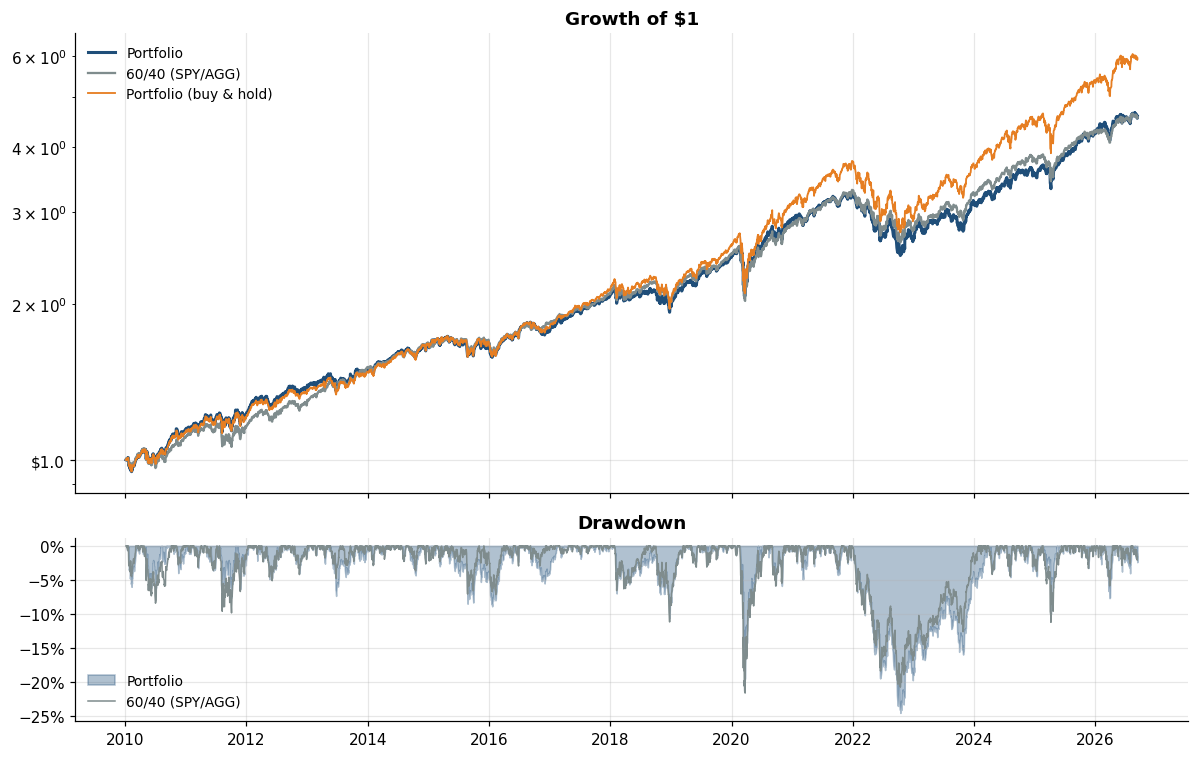

,peak,trough,recovery,depth,days_to_trough,days_to_recover,total_days
0,2021-12-27 00:00:00,2022-10-14 00:00:00,2024-03-27 00:00:00,-24.6%,202,363,565
1,2020-02-19 00:00:00,2020-03-20 00:00:00,2020-06-08 00:00:00,-19.8%,22,54,76
2,2018-01-26 00:00:00,2018-12-24 00:00:00,2019-03-15 00:00:00,-10.6%,229,55,284
3,2025-02-20 00:00:00,2025-04-08 00:00:00,2025-05-13 00:00:00,-10.0%,33,24,57
4,2015-04-27 00:00:00,2016-01-20 00:00:00,2016-04-13 00:00:00,-8.9%,185,58,243


In [14]:
fig = plots.plot_growth(R["portfolio"], R["benchmark"], R["buy_hold"], benchmark_name); plots.save(fig, "01_growth_drawdown"); plt.show()
display(R["drawdowns"].style.format({"depth": "{:.1%}", "days_to_recover": "{:.0f}"}))
R["drawdowns"].to_csv("outputs/tables/drawdowns.csv")

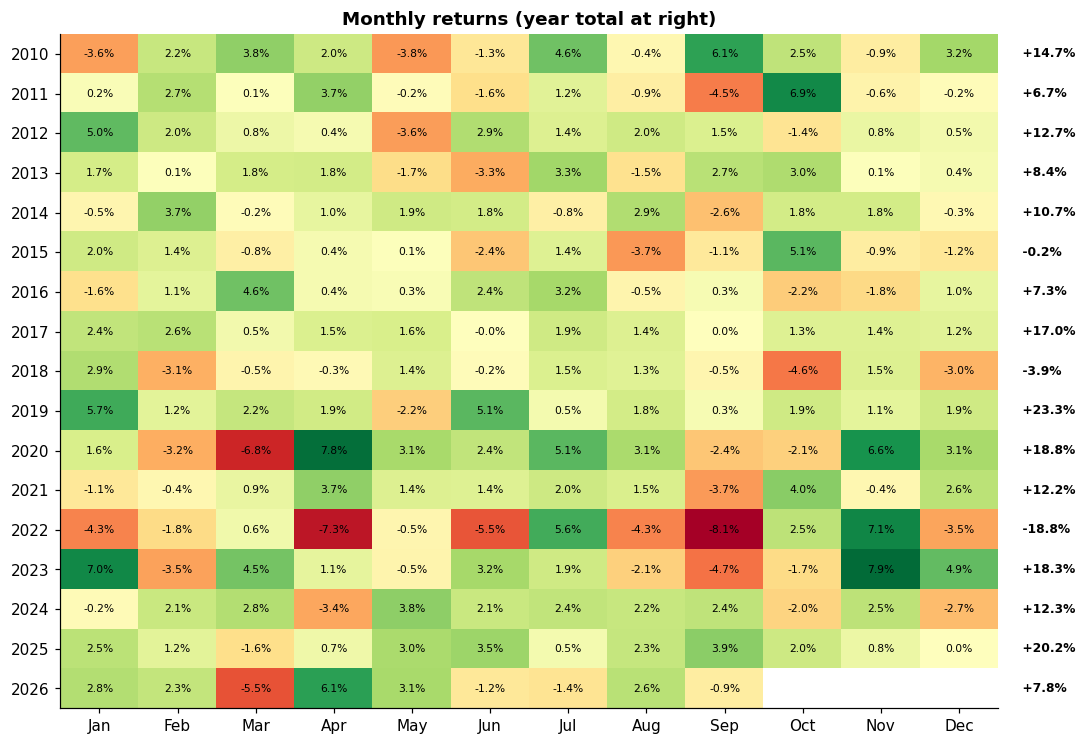

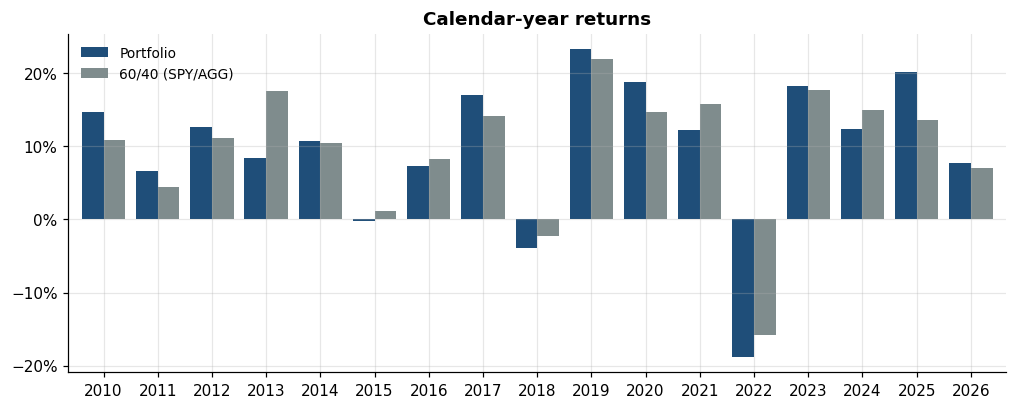

In [15]:
fig = plots.plot_monthly_heatmap(R["monthly"]); plots.save(fig, "02_monthly_heatmap"); plt.show()
fig = plots.plot_annual(R["annual"]); plots.save(fig, "03_annual_returns"); plt.show()
R["monthly"].to_csv("outputs/tables/monthly_returns.csv")

## 7. Rolling risk: volatility, beta, Sharpe

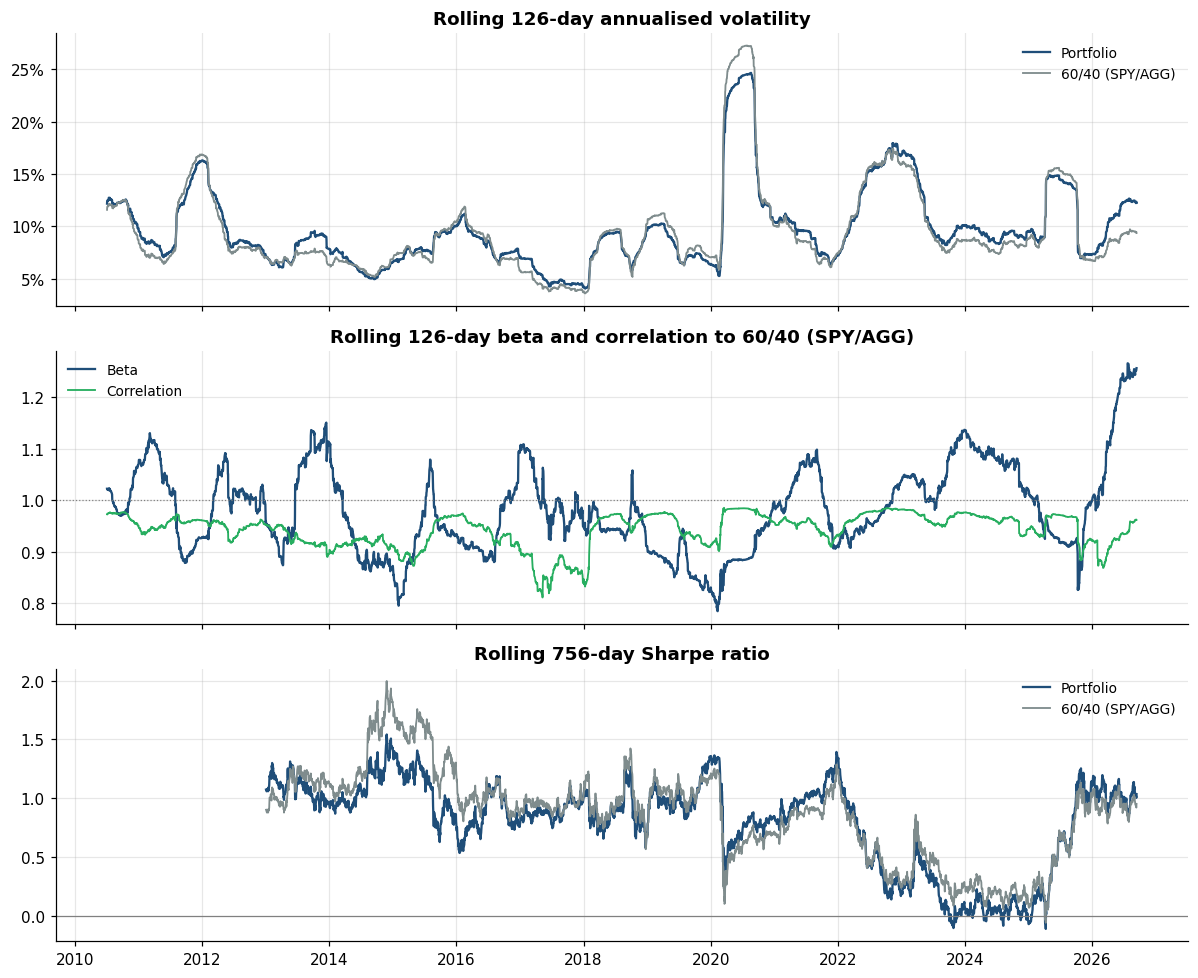

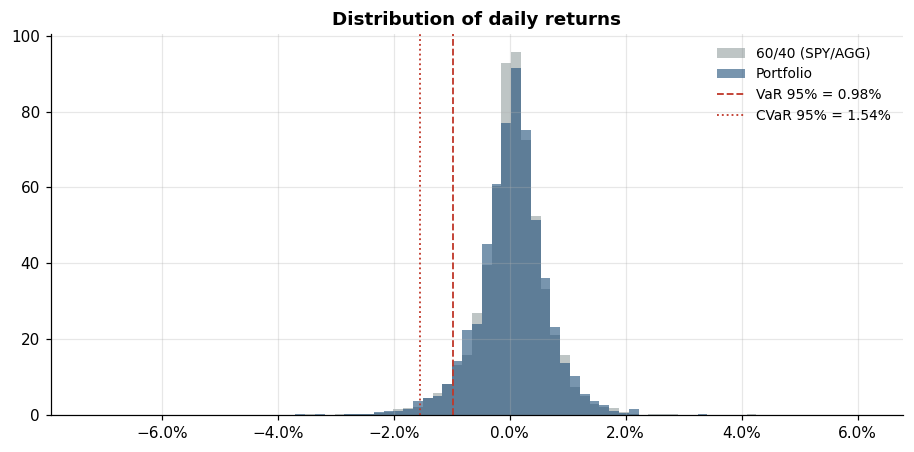

In [16]:
fig = plots.plot_rolling(R["rolling"], benchmark_name, DASH.rolling_window, DASH.long_window); plots.save(fig, "04_rolling"); plt.show()
fig = plots.plot_return_distribution(R["portfolio"], R["benchmark"], DASH.var_level); plots.save(fig, "05_distribution"); plt.show()

## 8. Risk decomposition: where the risk actually sits

Euler decomposition of portfolio volatility using the trailing 1-year covariance.
`risk_to_weight` above 1 means the position contributes more risk than capital.

,weight,stand_alone_vol,marginal_ctr,component_ctr,pct_of_risk,beta_to_portfolio,risk_to_weight
SPY,30.0%,12.8%,11.61%,3.48%,32.8%,1.09,1.09x
QQQ,10.0%,19.6%,16.89%,1.69%,15.9%,1.59,1.59x
EFA,10.0%,15.7%,14.02%,1.40%,13.2%,1.32,1.32x
EEM,5.0%,25.0%,21.36%,1.07%,10.1%,2.01,2.01x
IEF,15.0%,4.6%,2.36%,0.35%,3.3%,0.22,0.22x
TLT,10.0%,9.1%,3.92%,0.39%,3.7%,0.37,0.37x
LQD,5.0%,5.3%,3.31%,0.17%,1.6%,0.31,0.31x
GLD,10.0%,29.2%,18.11%,1.81%,17.1%,1.71,1.71x
VNQ,5.0%,13.6%,4.82%,0.24%,2.3%,0.45,0.45x


portfolio vol 10.60% | diversification ratio 1.33 | effective number of risk sources 5.2 (of 9)


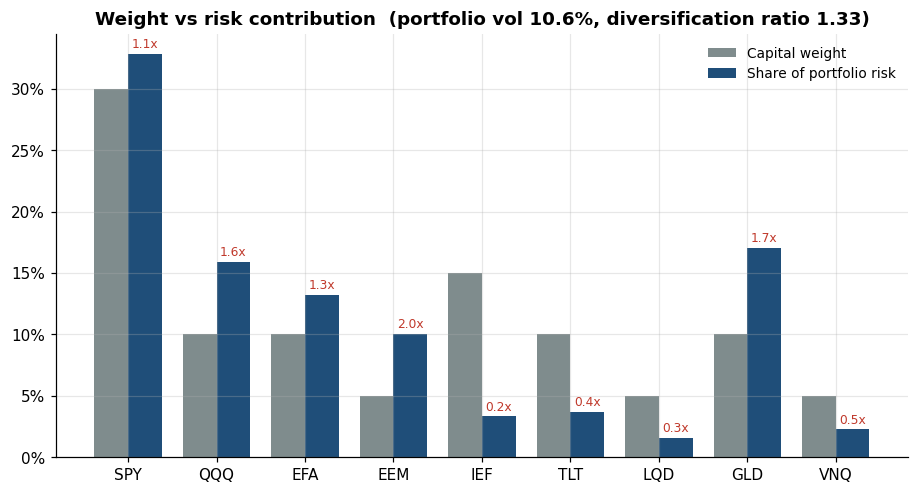

In [17]:
dec = R["decomposition"]
display(dec.style.format({"weight": "{:.1%}", "stand_alone_vol": "{:.1%}", "marginal_ctr": "{:.2%}", "component_ctr": "{:.2%}",
                          "pct_of_risk": "{:.1%}", "beta_to_portfolio": "{:.2f}", "risk_to_weight": "{:.2f}x"})
        .background_gradient(subset=["pct_of_risk"], cmap="Reds").background_gradient(subset=["risk_to_weight"], cmap="RdYlGn_r", vmin=0, vmax=2))
print(f"portfolio vol {dec.attrs['portfolio_vol']:.2%} | diversification ratio {dec.attrs['diversification_ratio']:.2f} | effective number of risk sources {dec.attrs['effective_n_risk']:.1f} (of {len(dec)})")
dec.to_csv("outputs/tables/risk_decomposition.csv")
fig = plots.plot_risk_vs_weight(dec); plots.save(fig, "06_risk_vs_weight"); plt.show()

,weight,component_ctr,pct_of_risk,risk_to_weight
Equity - US,40.0%,5.17%,48.8%,1.22x
Commodities,10.0%,1.81%,17.1%,1.71x
Equity - Intl,10.0%,1.40%,13.2%,1.32x
Equity - EM,5.0%,1.07%,10.1%,2.01x
Rates,25.0%,0.74%,7.0%,0.28x
Real Estate,5.0%,0.24%,2.3%,0.45x
Credit,5.0%,0.17%,1.6%,0.31x


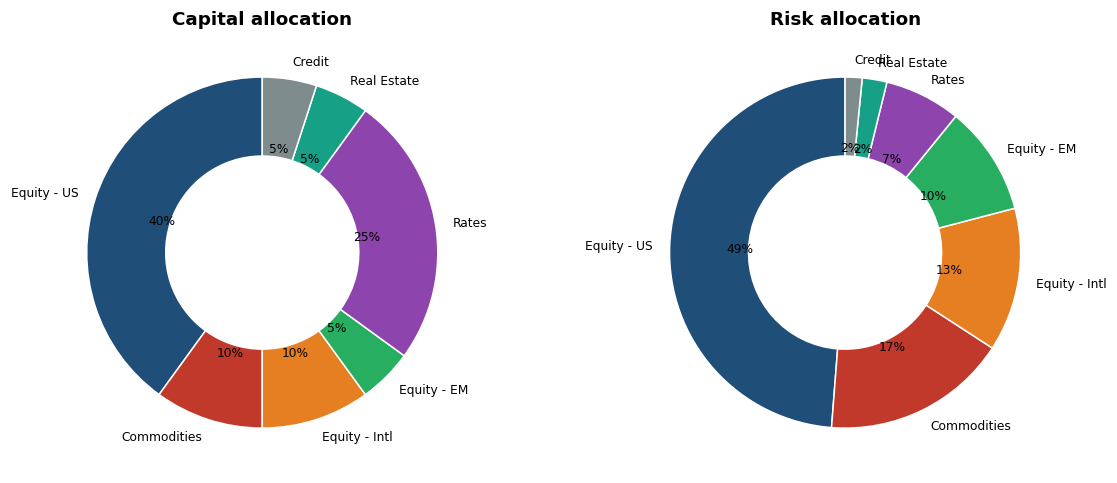

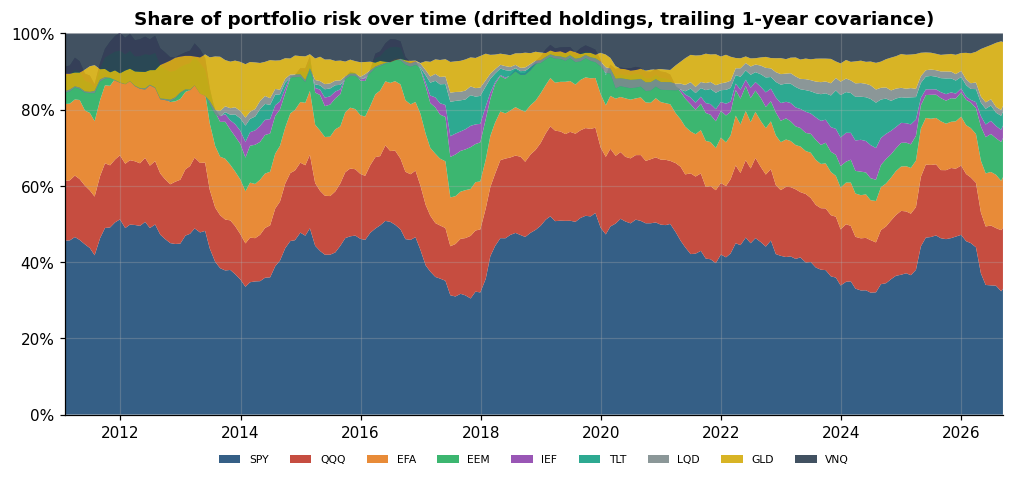

In [18]:
display(R["group_decomposition"].style.format({"weight": "{:.1%}", "component_ctr": "{:.2%}", "pct_of_risk": "{:.1%}", "risk_to_weight": "{:.2f}x"}))
fig = plots.plot_group_risk(R["group_decomposition"]); plots.save(fig, "07_group_risk"); plt.show()
fig = plots.plot_rolling_risk(R["rolling_risk"]); plots.save(fig, "08_rolling_risk"); plt.show()

## 9. Does the diversification survive stress?

Average pairwise correlation and each asset's correlation to the benchmark on the benchmark's
worst 10% of days versus the rest. For a multi-asset book the pairwise average can *fall* in
stress because Treasuries rally when equities sell off; the per-asset view shows which sleeves
provided that offset and which (credit, REITs, EM) did not.

,avg_pairwise_corr,n_days
All days,0.29,4197
Benchmark above 10% tail,0.27,3777
Benchmark worst 10% days,0.22,420


,calm,stress,change,avg_ret_on_stress_days
TLT,-0.07,-0.12,-0.05,0.30%
IEF,-0.02,-0.12,-0.10,0.11%
GLD,0.12,0.07,-0.06,-0.13%
LQD,0.28,0.44,+0.16,-0.24%
EEM,0.69,0.67,-0.02,-1.89%
VNQ,0.67,0.73,+0.07,-1.70%
EFA,0.79,0.75,-0.04,-1.77%
QQQ,0.88,0.82,-0.06,-2.21%
SPY,0.98,0.96,-0.02,-1.93%


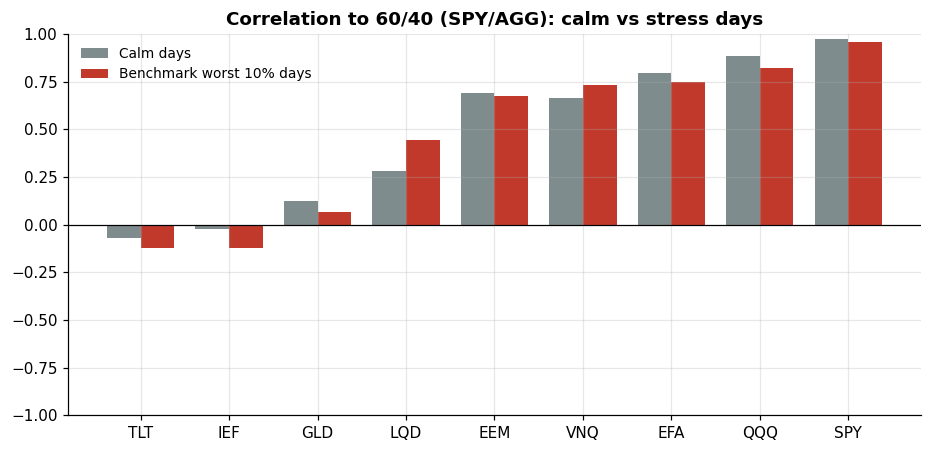

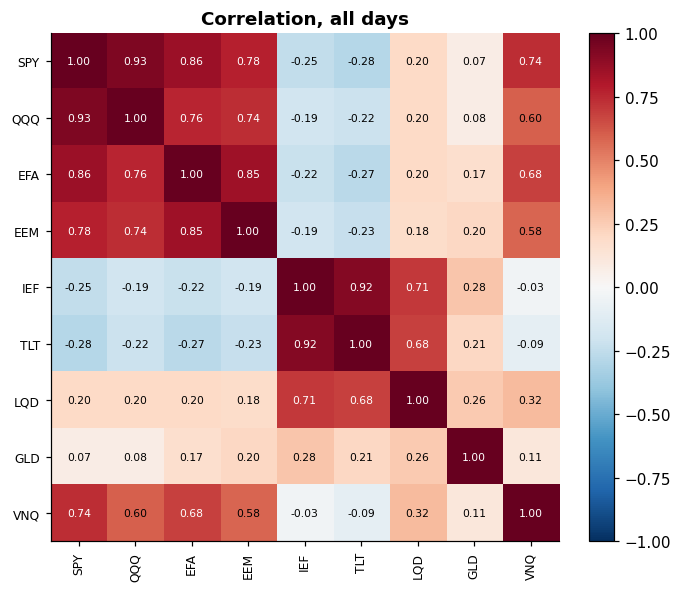

In [19]:
display(R["regimes"]["summary"].style.format({"avg_pairwise_corr": "{:.2f}", "n_days": "{:.0f}"}))
display(R["regimes"]["to_benchmark"].style.format({"calm": "{:.2f}", "stress": "{:.2f}", "change": "{:+.2f}", "avg_ret_on_stress_days": "{:.2%}"})
        .background_gradient(subset=["stress"], cmap="RdBu_r", vmin=-1, vmax=1))
fig = plots.plot_regime_correlation(R["regimes"]["to_benchmark"], benchmark_name); plots.save(fig, "09_regime_correlation"); plt.show()
fig = plots.plot_correlation(R["regimes"]["full"], "Correlation, all days"); plots.save(fig, "10_correlation"); plt.show()

## 10. Historical stress scenarios

,start,end,days,portfolio,benchmark,worst_day,worst_asset,worst_asset_return
scenario,,,,,,,,
Euro crisis / US downgrade (2011),2011-07-22,2011-10-03,51,-6.4%,-9.7%,-3.0%,EEM,-27.9%
Taper tantrum (2013),2013-05-02,2013-06-24,37,-6.0%,-2.0%,-2.6%,EEM,-14.4%
China deval / vol spike (2015),2015-08-10,2015-08-25,12,-5.6%,-5.8%,-2.4%,EEM,-12.6%
Q4 2018 sell-off,2018-09-20,2018-12-24,66,-8.7%,-10.7%,-1.8%,QQQ,-21.1%
Covid crash (2020),2020-02-19,2020-03-23,24,-18.2%,-21.4%,-6.0%,VNQ,-42.3%
Rate shock (2022),2022-01-03,2022-10-12,196,-23.9%,-20.3%,-3.3%,QQQ,-33.7%
SVB / regional banks (2023),2023-03-08,2023-03-17,8,1.3%,0.1%,-0.8%,VNQ,-4.8%
Aug 2024 yen-carry unwind,2024-07-16,2024-08-05,15,-3.4%,-3.8%,-1.7%,QQQ,-12.3%


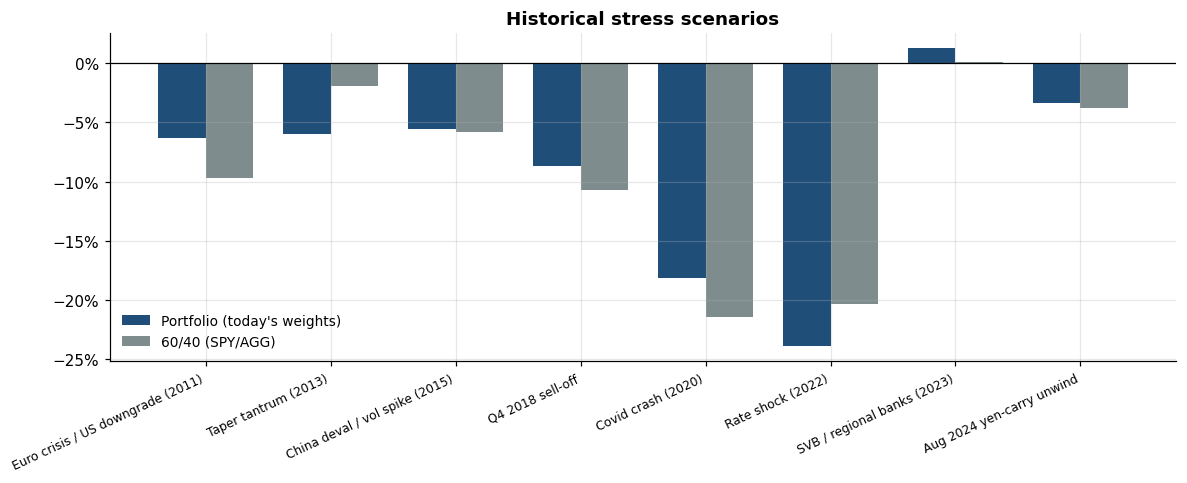

In [20]:
display(R["stress"].style.format({"portfolio": "{:.1%}", "benchmark": "{:.1%}", "worst_day": "{:.1%}", "worst_asset_return": "{:.1%}"})
        .background_gradient(subset=["portfolio"], cmap="RdYlGn", vmin=-0.3, vmax=0.1))
R["stress"].to_csv("outputs/tables/stress_scenarios.csv")
fig = plots.plot_stress(R["stress"], benchmark_name); plots.save(fig, "11_stress"); plt.show()

## 11. What-if: a proposed reallocation

Absolute weight changes; the rest of the book is renormalised. Ex-ante vol and risk shares
before and after, using the same trailing covariance. Change the dict and re-run.

change {'GLD': -0.05, 'IEF': 0.05}: vol 10.60% -> 9.89%, historical-mean return 9.93% -> 9.60% (a noisy estimate; treat with caution)


,weight_before,weight_after,risk_share_before,risk_share_after
SPY,30.0%,30.0%,32.8%,36.1%
QQQ,10.0%,10.0%,15.9%,17.5%
EFA,10.0%,10.0%,13.2%,14.3%
EEM,5.0%,5.0%,10.1%,10.8%
IEF,15.0%,20.0%,3.3%,5.0%
TLT,10.0%,10.0%,3.7%,4.3%
LQD,5.0%,5.0%,1.6%,1.8%
GLD,10.0%,5.0%,17.1%,7.7%
VNQ,5.0%,5.0%,2.3%,2.5%


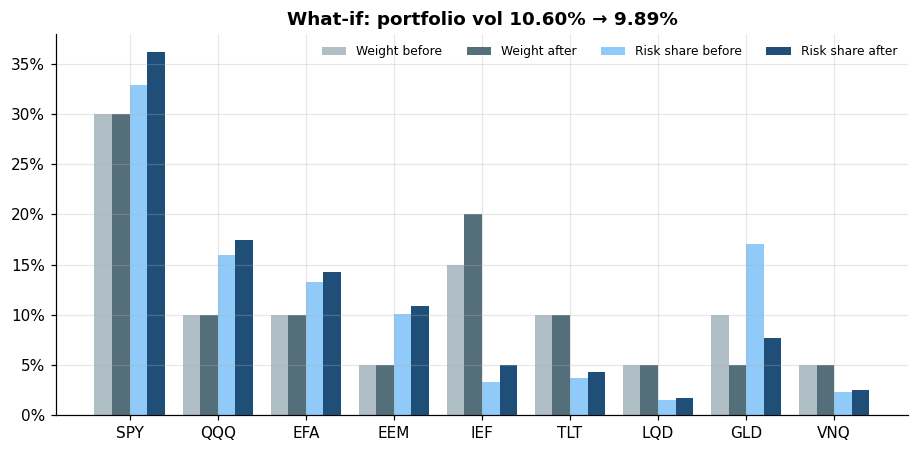

In [21]:
CHANGES = {"GLD": -0.05, "IEF": +0.05}      # e.g. trim gold, add duration
CHANGES = {k: v for k, v in CHANGES.items() if k in R["weights"].index} or {R["decomposition"]["marginal_ctr"].idxmax(): -0.05, R["decomposition"]["marginal_ctr"].idxmin(): +0.05}
wi = risk.what_if(R["weights"], R["cov"], R["mu"], CHANGES)
print(f"change {CHANGES}: vol {wi.attrs['vol_before']:.2%} -> {wi.attrs['vol_after']:.2%}"
      + (f", historical-mean return {wi.attrs['ret_before']:.2%} -> {wi.attrs['ret_after']:.2%} (a noisy estimate; treat with caution)" if "ret_before" in wi.attrs else ""))
display(wi.style.format("{:.1%}"))
fig = plots.plot_what_if(wi); plots.save(fig, "12_what_if"); plt.show()

## 12. Per-asset statistics

In [22]:
display(met.format_summary(R["per_asset"]))
R["per_asset"].to_csv("outputs/tables/per_asset.csv")

,SPY,QQQ,EFA,EEM,IEF,TLT,LQD,GLD,VNQ
Total return,803.65%,1676.25%,208.55%,124.68%,49.90%,46.85%,83.84%,263.18%,306.06%
CAGR,14.13%,18.86%,7.00%,4.98%,2.46%,2.33%,3.72%,8.05%,8.78%
Volatility,17.07%,20.65%,18.34%,21.64%,6.57%,14.91%,7.58%,16.77%,20.28%
Downside deviation,12.14%,14.54%,13.27%,15.53%,4.62%,10.51%,5.37%,12.03%,14.63%
Sharpe,0.77,0.87,0.38,0.26,0.17,0.13,0.32,0.46,0.44
Sortino,1.09,1.23,0.52,0.37,0.25,0.18,0.46,0.64,0.61
Max drawdown,-33.72%,-35.12%,-34.19%,-39.82%,-23.92%,-48.35%,-24.95%,-45.56%,-42.40%
Max DD length (days),120,494,707,1149,1534,1534,1248,2248,289
Calmar,0.42,0.54,0.20,0.13,0.10,0.05,0.15,0.18,0.21
Daily VaR 95%,1.64%,2.07%,1.75%,2.08%,0.65%,1.49%,0.70%,1.67%,1.92%


## 13. Export the dashboard

One HTML file with the KPI cards, every figure and the key tables embedded. Open it in a
browser, attach it to an e-mail, or drop it on a shared drive.

In [23]:
figs = [
    ("Growth and drawdown", plots.plot_growth(R["portfolio"], R["benchmark"], R["buy_hold"], benchmark_name)),
    ("Weight vs risk contribution", plots.plot_risk_vs_weight(R["decomposition"])),
    ("Risk by asset class", plots.plot_group_risk(R["group_decomposition"])),
    ("Risk share over time", plots.plot_rolling_risk(R["rolling_risk"])),
    ("Rolling volatility, beta, Sharpe", plots.plot_rolling(R["rolling"], benchmark_name, DASH.rolling_window, DASH.long_window)),
    ("Monthly returns", plots.plot_monthly_heatmap(R["monthly"])),
    ("Correlation to benchmark: calm vs stress", plots.plot_regime_correlation(R["regimes"]["to_benchmark"], benchmark_name)),
    ("Stress scenarios", plots.plot_stress(R["stress"], benchmark_name)),
]
label = {"ME": "monthly rebalancing", "QE": "quarterly rebalancing", None: "buy and hold"}.get(REBALANCE, f"{REBALANCE} rebalancing")
path = report.build_report(R, figs, "Portfolio Risk & Performance Dashboard", "outputs/dashboard.html", label)
print("written:", path, f"({os.path.getsize(path)/1e6:.1f} MB)")
try:
    from google.colab import files  # type: ignore
    files.download(path)
except Exception:
    from IPython.display import HTML, display as _d
    _d(HTML(f'<a href="{path}" target="_blank">open dashboard.html</a>'))

written: outputs/dashboard.html (1.3 MB)


## 14. Reading the results

Write your own after each run; the pattern on the default portfolio has been:

1. **Capital allocation is not risk allocation.** The 25% Treasury sleeve carries under 10% of
   the risk; gold at 10% carries close to 20%; EM equity at 5% roughly doubles its weight in risk
   terms. The book is ~75% equity-like in risk while looking 55% equity by weight.
2. **Rebalancing changes the risk profile more than the return.** Buy-and-hold drifted to a
   higher beta and deeper drawdowns for a similar Sharpe; the value of rebalancing shows up in
   risk control, not in alpha.
3. **The hedge mostly held; credit did not.** Against a 60/40 benchmark (which already holds
   bonds) Treasury correlation goes mildly negative on stress days, while investment-grade credit
   correlation *rises* (roughly 0.3 → 0.45): credit behaves like equity exactly when you need it
   not to. 2022 is the exception that proves the rule: when rates were the shock, the Treasury
   sleeve deepened the drawdown instead of cushioning it.
4. **Alpha versus a 60/40 is statistically zero.** The t-stat on Jensen's alpha is well below 2;
   what differs is the shape of risk, not the level of return.

## 15. Potential upgrades

| Upgrade | Why |
|---|---|
| Factor-based risk decomposition (equity, rates, credit, FX, commodity betas) | Project 2 in this track; explains *why* two assets co-move |
| Ex-ante VaR/CVaR via Monte Carlo with fat-tailed marginals and a t-copula | Historical VaR is bounded by the sample; the 2008 tail is not in a 2010-start dataset |
| Liquidity-adjusted risk and position-size limits | Turns the dashboard from descriptive into a limits framework |
| Attribution: allocation vs selection vs interaction (Brinson) against the benchmark | Standard institutional monthly reporting |
| Scheduled run (GitHub Actions cron) with e-mailed HTML and threshold alerts | The operating version of this notebook |
| Interactive front end (Plotly Dash / Streamlit) with weight sliders driving the what-if | For portfolio managers who will not open a notebook |